# 🎓 Student Performance Prediction

## 1. Business Understanding

### Problem Statement
A school district wants to identify high school students who are
at risk of poor academic performance before it's too late to help them.

### Goal
Build machine learning models to predict students' final grade (G3)
in Portuguese — and identify which factors put a student at risk.

### Why It Matters
- Early intervention can prevent students from failing
- Schools can allocate tutoring and support more effectively
- Data-driven decisions instead of guesswork

### Our Approach
We will tackle this as **two problems**:
1. **Regression** → Predict the exact G3 score
2. **Classification** → Predict if a student is "at-risk" or not

### Most Important Metric
- Regression: **RMSE** (how far off our predictions are)
- Classification: **Recall** (we don't want to miss at-risk students)

### Target Variable
- **G3**: Final period grade (0–20)

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Sklearn - Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib

# Sklearn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Sklearn - Evaluation
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report,
                             ConfusionMatrixDisplay)

# Sklearn - Inspection
from sklearn.inspection import permutation_importance

# Settings
import warnings
SEED = 321
np.random.seed(SEED)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use(('ggplot', 'tableau-colorblind10'))
sns.set_context(context='notebook', font_scale=1.2)

print('✅ Libraries imported successfully!')



✅ Libraries imported successfully!


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )
  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

In [86]:
def classification_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    if verbose:
        header = "-"*70
        print(header, f" Classification Metrics: {label}", header, sep='\n')
        print(classification_report(y_true, y_pred))
    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                             verbose=True, output_frame=False):
    y_train_pred = model.predict(X_train)
    classification_metrics(y_train, y_train_pred,
                           label='Training Data', verbose=verbose,
                           output_dict=output_frame)
    print()
    y_test_pred = model.predict(X_test)
    classification_metrics(y_test, y_test_pred,
                           label='Test Data', verbose=verbose,
                           output_dict=output_frame)

print('✅ Classification functions ready!')

✅ Classification functions ready!


#**Load Data + Initial Inspection**

In [4]:
# Load Data
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vS6xDKNpWkBBdhZSqepy48bXo55QnRv1Xy6tXTKYzZLMPjZozMfYhHQjAcC8uj9hQ/pub?output=xlsx"
df = pd.read_excel(url, sheet_name='student-por')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Dataset Shape: (649, 33)
Rows: 649
Columns: 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12


In [5]:
# summarize_df function
def summarize_df(df_):
    df = df_.copy()
    report = pd.DataFrame({
        'dtype': df.dtypes,
        '# null': df.isna().sum(),
        'null (%)': (df.isna().sum() / len(df) * 100).round(2),
        'nunique': df.nunique(),
        'min': df.min(),
        'max': df.max()
    })
    report.index.name = 'Column'
    return report.reset_index()

summarize_df(df)

,Column,dtype,# null,null (%),nunique,min,max
0,school,object,0,0.0,2,GP,MS
1,sex,object,0,0.0,2,F,M
2,age,int64,0,0.0,8,15,22
3,address,object,0,0.0,2,R,U
4,famsize,object,0,0.0,2,GT3,LE3
5,Pstatus,object,0,0.0,2,A,T
6,Medu,int64,0,0.0,5,0,4
7,Fedu,int64,0,0.0,5,0,4
8,Mjob,object,0,0.0,5,at_home,teacher
9,Fjob,object,0,0.0,5,at_home,teacher


In [6]:
# Duplicates
print(f'Duplicates: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'After removing: {df.shape}')
else:
    print('No duplicates ✅')

Duplicates: 0
No duplicates ✅


## **Customizing Our Plots**

Before modeling, we set consistent visual styles across all plots.

In [7]:
## Customization Options
plt.style.use(('ggplot','tableau-colorblind10'))
sns.set_context(context='notebook', font_scale= 1.2)
plt.rcParams['savefig.transparent'] = False
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.facecolor']='white'

#**Explore Target Variable (G3)**

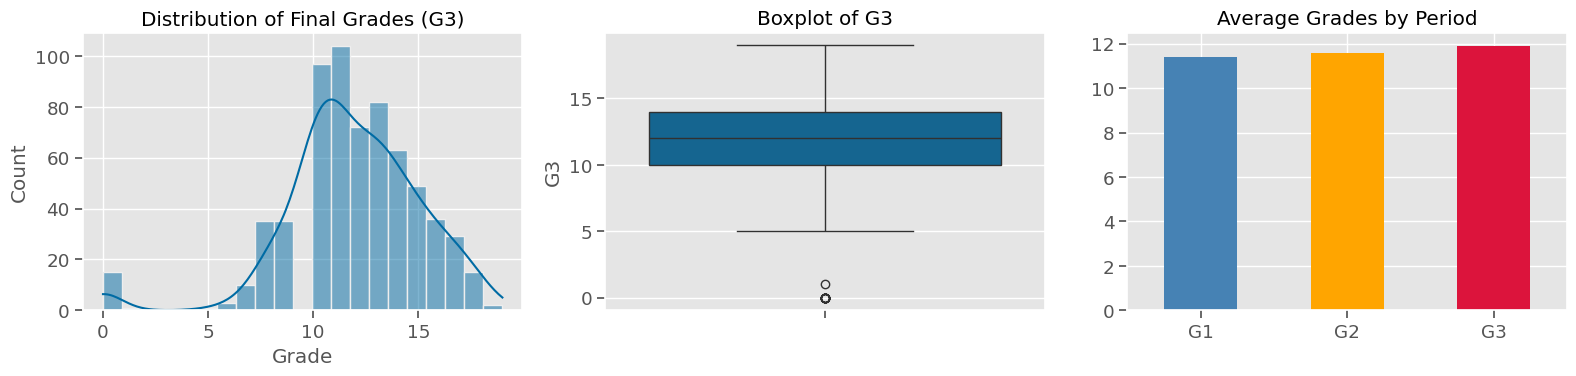


G3 Stats:
count    649.00
mean      11.91
std        3.23
min        0.00
25%       10.00
50%       12.00
75%       14.00
max       19.00
Name: G3, dtype: float64

Students with G3 = 0: 15


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
sns.histplot(data=df, x='G3', ax=axes[0], kde=True)
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Grade')

# Boxplot
sns.boxplot(data=df, y='G3', ax=axes[1])
axes[1].set_title('Boxplot of G3')

# G1 vs G2 vs G3 comparison
df[['G1', 'G2', 'G3']].mean().plot(kind='bar', ax=axes[2], color=['steelblue', 'orange', 'crimson'])
axes[2].set_title('Average Grades by Period')
axes[2].set_xticklabels(['G1', 'G2', 'G3'], rotation=0)

plt.tight_layout()
plt.show()

print(f"\nG3 Stats:\n{df['G3'].describe().round(2)}")
print(f"\nStudents with G3 = 0: {(df['G3']==0).sum()}")

## EDA — Visualizing Grades

**Key Observations:**
- Mean final grade (G3) = 11.91 out of 20
- Median = 12, meaning half the students scored above 12
- 15 students received G3 = 0 (likely withdrew or failed entirely)
- Distribution is slightly left-skewed — most students score between 10–15
- Average grades are consistent across periods: G1 ≈ G2 ≈ G3 ≈ 12

#**Univariate — Numeric Features:**

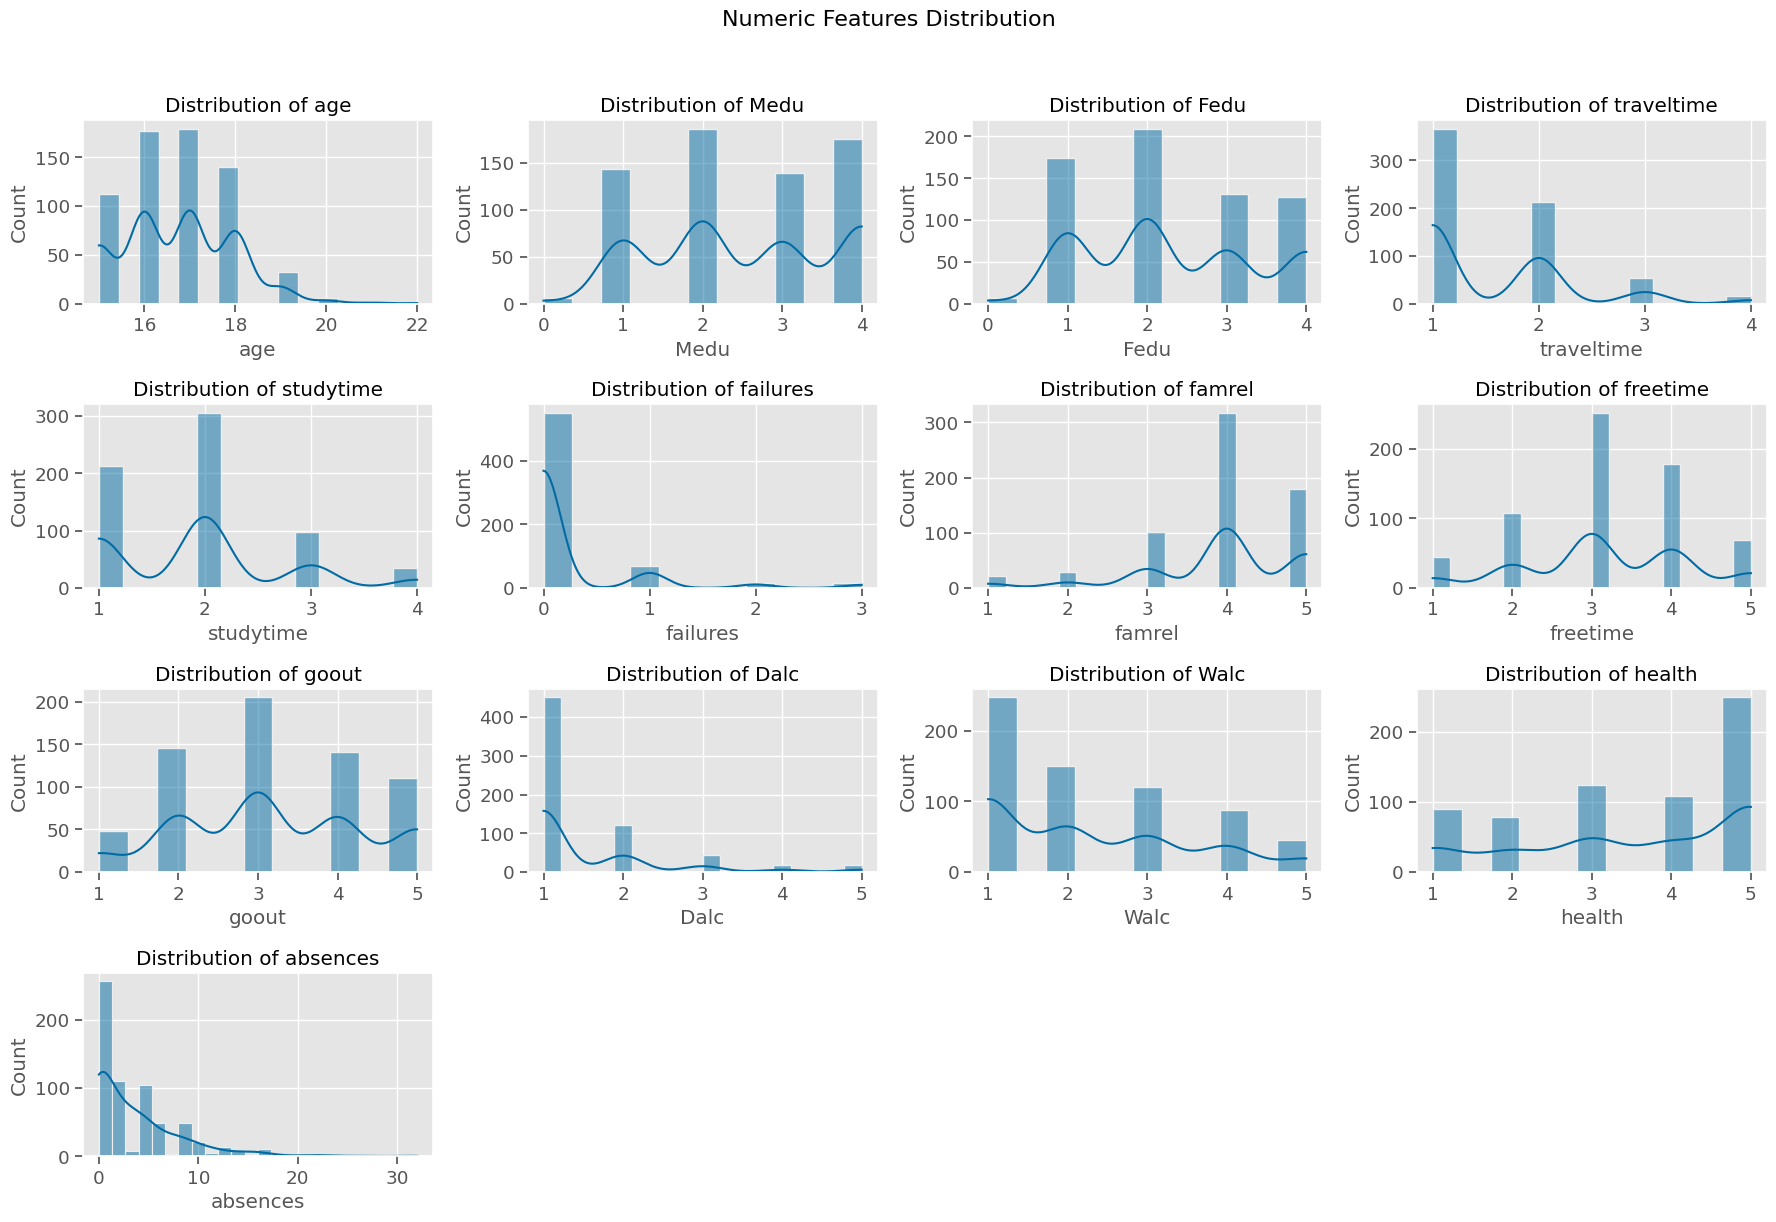

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['G1','G2','G3']]

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Numeric Features — Key Observations

- **Age**: Most students are 16–17 years old
- **Medu/Fedu**: Parents' education is spread across all levels,
  with many having higher education (level 4)
- **Travel time**: Majority travel less than 15 minutes to school
- **Study time**: Most students study 2–5 hours per week (level 2)
- **Failures**: Most students have 0 past failures —
  very few have failed 3+ times
- **Alcohol (Dalc/Walc)**: Most students report very low consumption
- **Absences**: Right-skewed — most students have few absences,
  but some outliers exceed 30 days

#**Univariate — Categorical Features:**

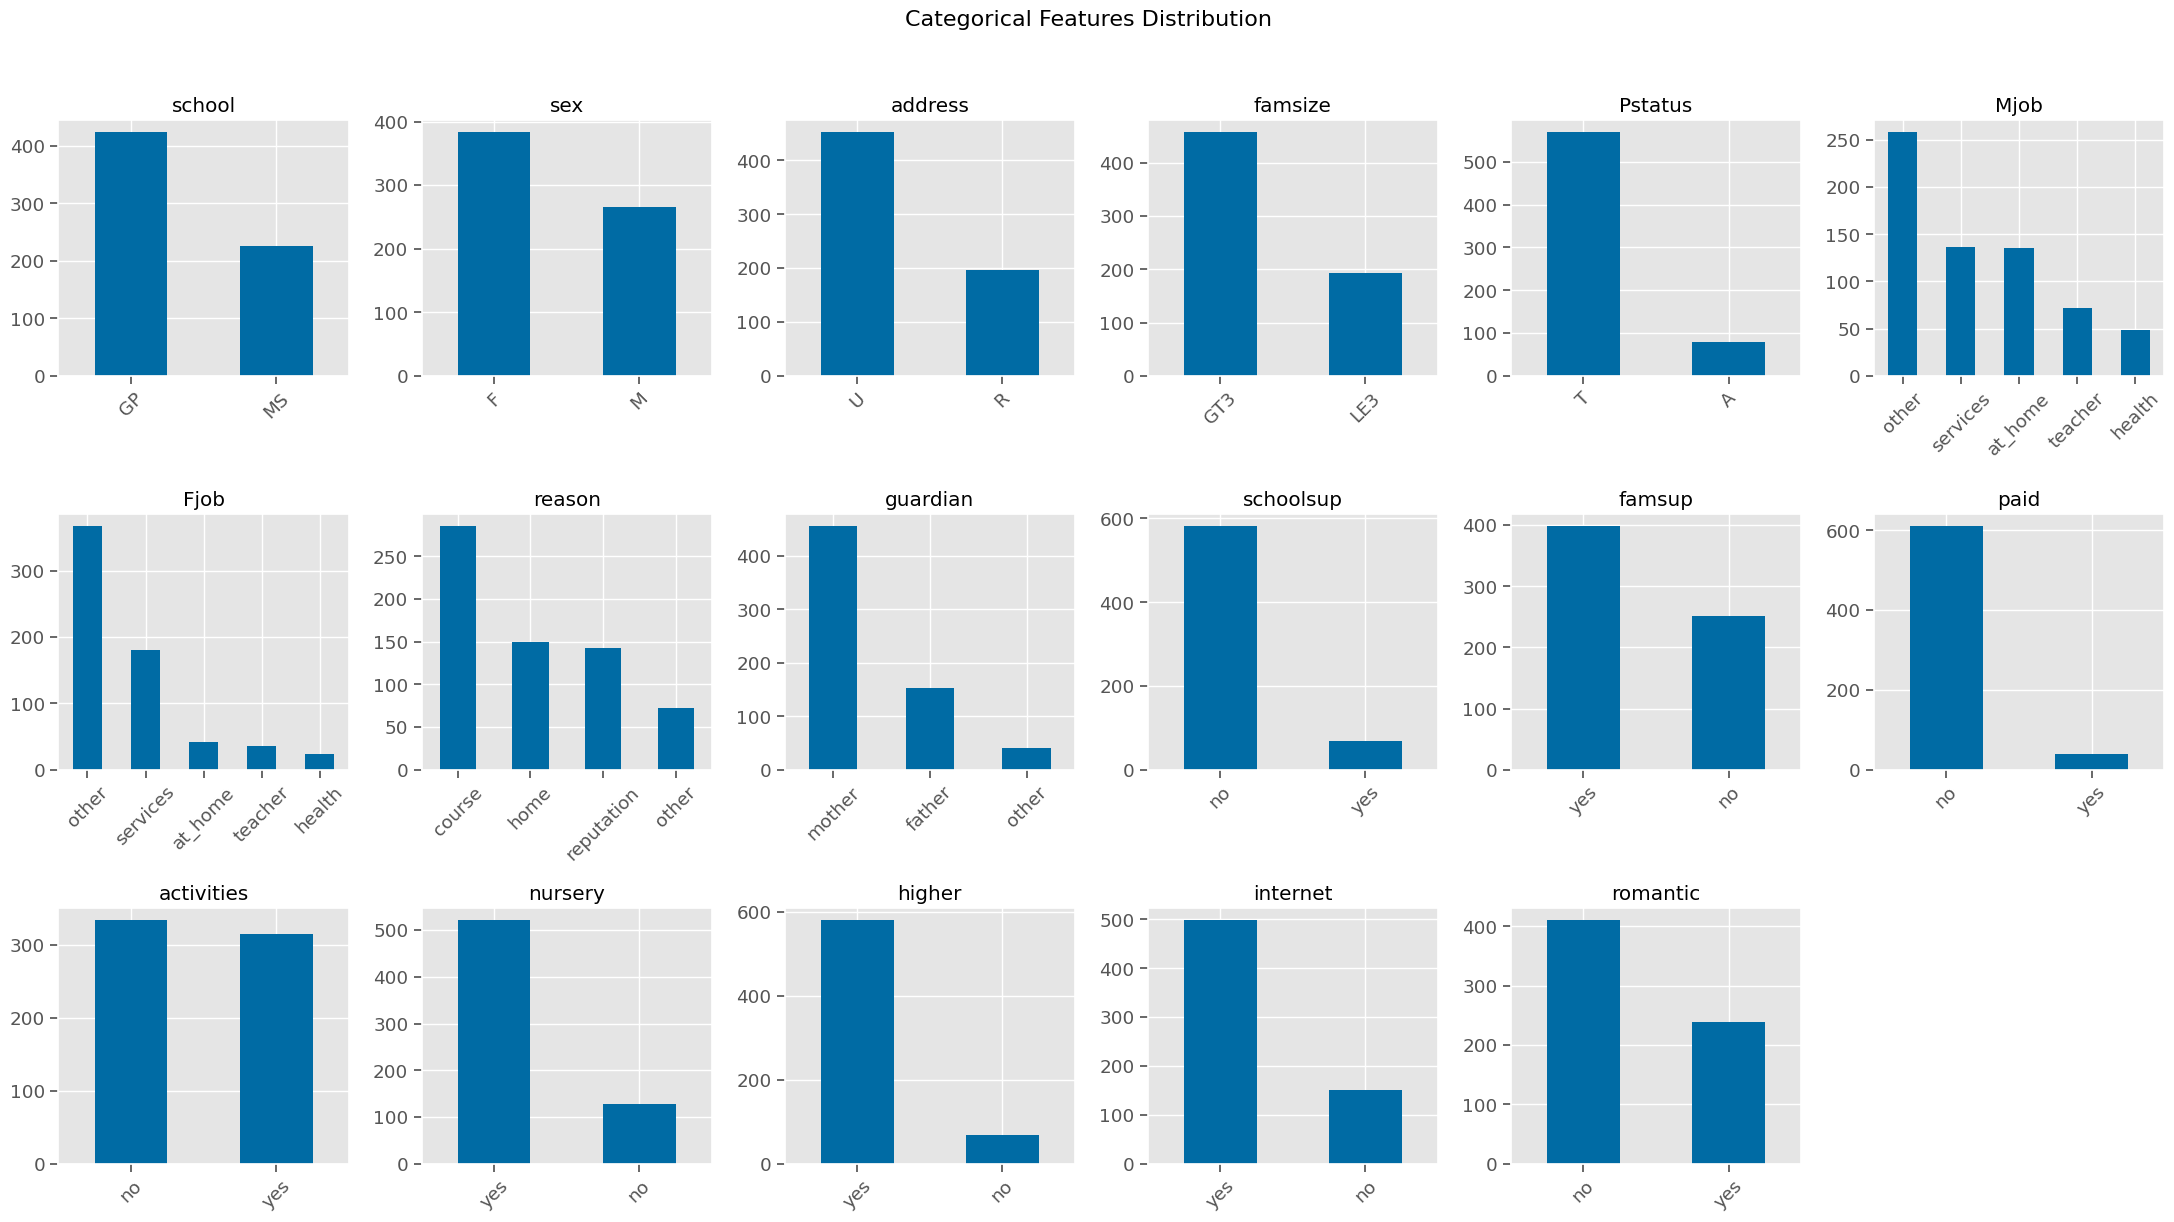

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(3, 6, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Categorical Features — Key Observations

- **School**: Majority of students attend Gabriel Pereira (GP)
- **Sex**: Slightly more female students than male
- **Address**: Most students live in urban areas
- **Family size**: Most families have more than 3 members (GT3)
- **Parent status**: Most parents live together (T)
- **Higher education**: Vast majority want to pursue higher education
- **Internet**: Most students have internet access at home
- **Romantic**: Most students are not in a romantic relationship

#**Multivariate — Correlation Heatmap:**

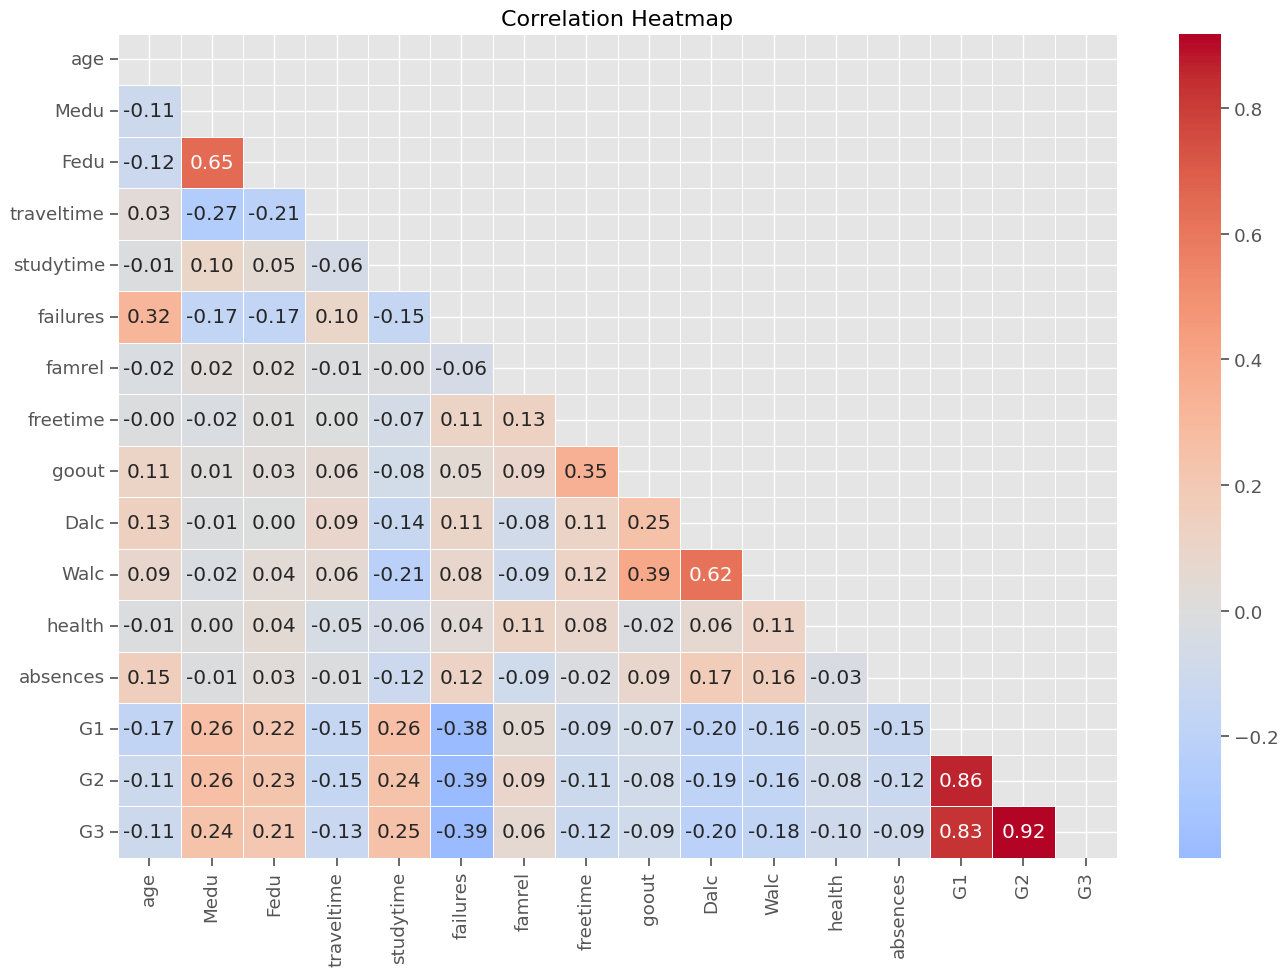


Top Features Correlated with G3:
G3            1.000
G2            0.919
G1            0.826
studytime     0.250
Medu          0.240
Fedu          0.212
famrel        0.063
goout        -0.088
absences     -0.091
health       -0.099
age          -0.107
freetime     -0.123
traveltime   -0.127
Walc         -0.177
Dalc         -0.205
failures     -0.393
Name: G3, dtype: float64


In [11]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlations with G3
print('\nTop Features Correlated with G3:')
print(corr['G3'].sort_values(ascending=False).round(3))

## Correlation Heatmap — Key Findings

**Strongest correlations with G3:**
- G2 → G3: 0.92 (very strong) — prior performance is the best predictor
- G1 → G3: 0.83 (strong) — first period grades highly predictive
- failures → G3: -0.39 (negative) — more past failures = lower final grade
- studytime → G3: 0.25 (positive) — more study time = better grade
- Medu → G3: 0.24 (positive) — mother's education has a positive effect
- Alcohol (Dalc/Walc) → G3: ~-0.20 (negative) — higher consumption = lower grades

**Important Note:** G1 and G2 are extremely strong predictors.
This confirms our earlier decision to build two models:
one with G1/G2 and one without.

#**Multivariate — Key Features vs G3**

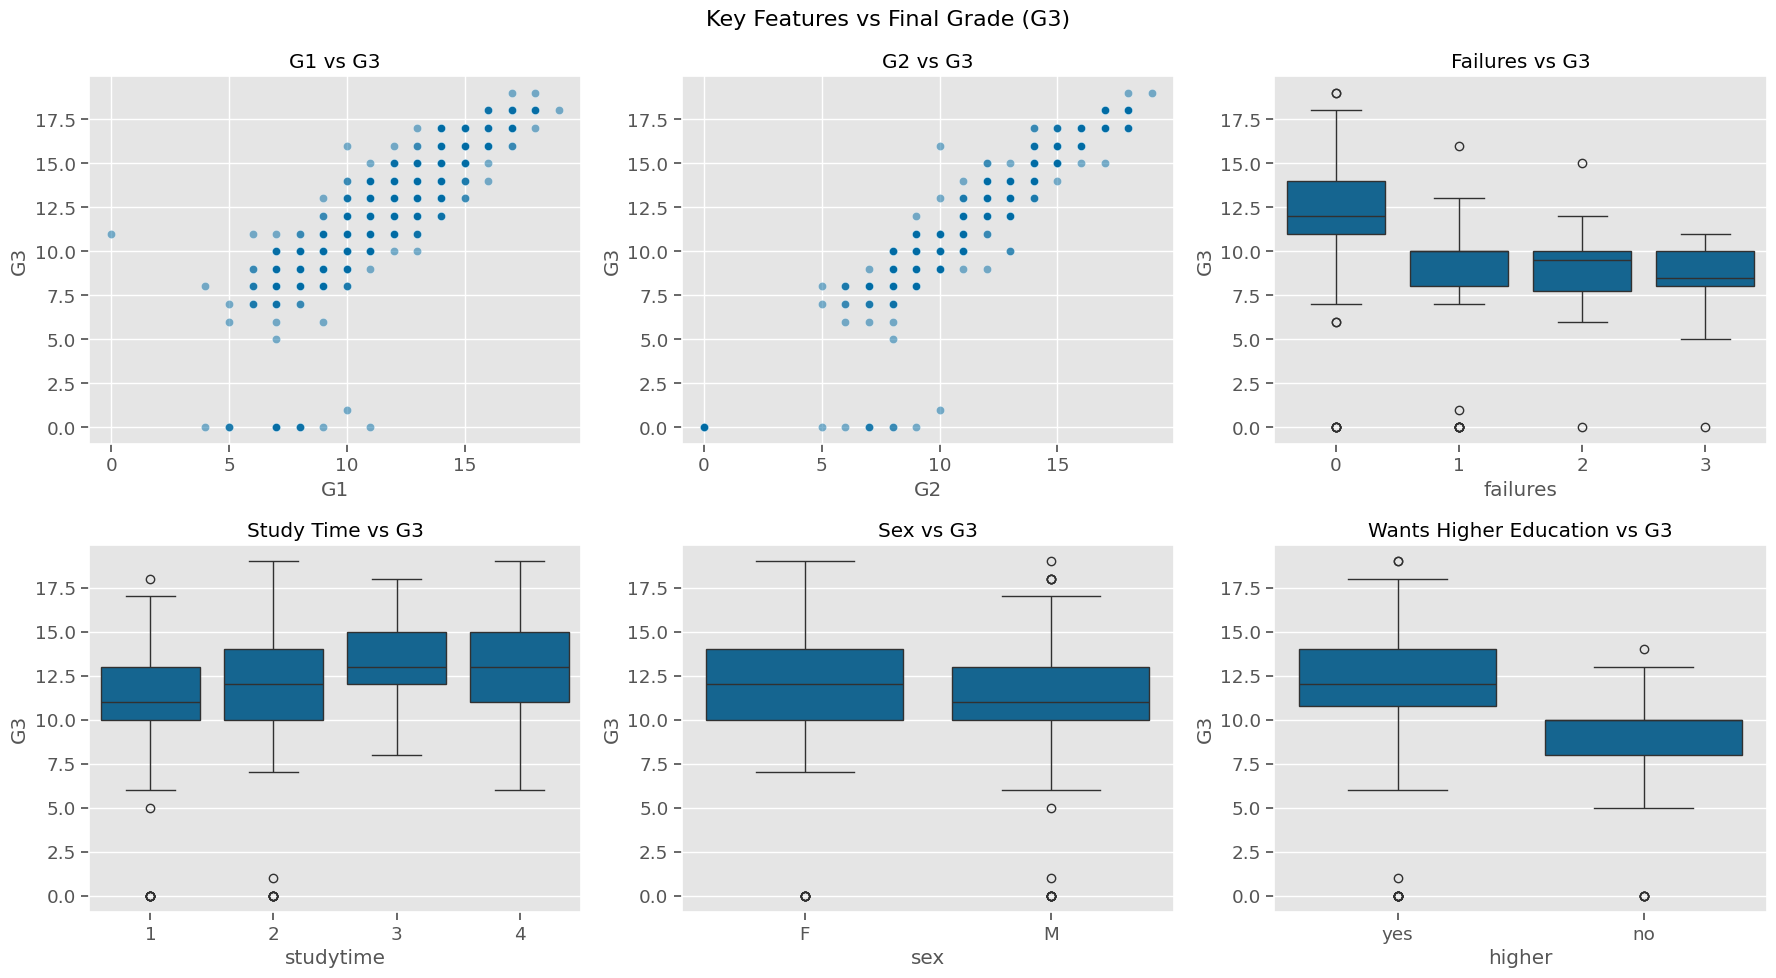

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# G1 vs G3
sns.scatterplot(data=df, x='G1', y='G3', ax=axes[0][0], alpha=0.5)
axes[0][0].set_title('G1 vs G3')

# G2 vs G3
sns.scatterplot(data=df, x='G2', y='G3', ax=axes[0][1], alpha=0.5)
axes[0][1].set_title('G2 vs G3')

# Failures vs G3
sns.boxplot(data=df, x='failures', y='G3', ax=axes[0][2])
axes[0][2].set_title('Failures vs G3')

# Studytime vs G3
sns.boxplot(data=df, x='studytime', y='G3', ax=axes[1][0])
axes[1][0].set_title('Study Time vs G3')

# Sex vs G3
sns.boxplot(data=df, x='sex', y='G3', ax=axes[1][1])
axes[1][1].set_title('Sex vs G3')

# Higher education vs G3
sns.boxplot(data=df, x='higher', y='G3', ax=axes[1][2])
axes[1][2].set_title('Wants Higher Education vs G3')

plt.suptitle('Key Features vs Final Grade (G3)', fontsize=16)
plt.tight_layout()
plt.show()

## Key Features vs G3 — Observations

- **G1 & G2 vs G3**: Strong linear relationship —
  students who performed well in earlier periods
  consistently score higher in G3
- **Failures vs G3**: Students with 0 failures average ~12,
  while those with 1+ failures drop to ~9–10
- **Study Time vs G3**: Positive trend — more study time
  correlates with slightly better grades
- **Sex vs G3**: Female students score marginally higher on average
- **Higher Education vs G3**: Students who want to pursue
  higher education score significantly better (median ~12 vs ~9)

#**Create At-Risk Column (Regression → Classification)**

In [13]:
# # At-risk = G3 less than 10 (failing grade)
# df['at_risk'] = (df['G3'] < 10).astype(int)

# print('At-Risk Distribution:')
# print(df['at_risk'].value_counts())
# print(f'\nAt-Risk Rate: {df["at_risk"].mean()*100:.2f}%')

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# df['at_risk'].value_counts().plot(kind='bar', ax=axes[0],
#                                    color=['steelblue', 'crimson'])
# axes[0].set_title('At-Risk Distribution - Counts')
# axes[0].set_xticklabels(['Not At-Risk (0)', 'At-Risk (1)'], rotation=0)

# df['at_risk'].value_counts(normalize=True).plot(kind='bar', ax=axes[1],
#                                                   color=['steelblue', 'crimson'])
# axes[1].set_title('At-Risk Distribution - Percentage')
# axes[1].set_xticklabels(['Not At-Risk (0)', 'At-Risk (1)'], rotation=0)

# plt.tight_layout()
# plt.show()

## At-Risk Distribution — Key Findings

- **Not At-Risk (0)**: ~540 students (≈83%)
- **At-Risk (1)**: ~105 students (≈17%)

**⚠️ Class Imbalance Detected:**
The dataset is imbalanced — only 17% of students are at-risk.
This means we must:
1. Use **Recall** as our primary metric
   (we cannot afford to miss at-risk students)
2. Apply **class_weight='balanced'** in our models
3. Avoid relying on Accuracy alone
   (a model predicting everyone as "safe" would still get 83% accuracy!)

## **EDA**

### Visualizing Grades

Before modeling, we explore our target variable G3
to understand the distribution of final grades.

Text(0.5, 1.0, 'Distribution of Final Grades')

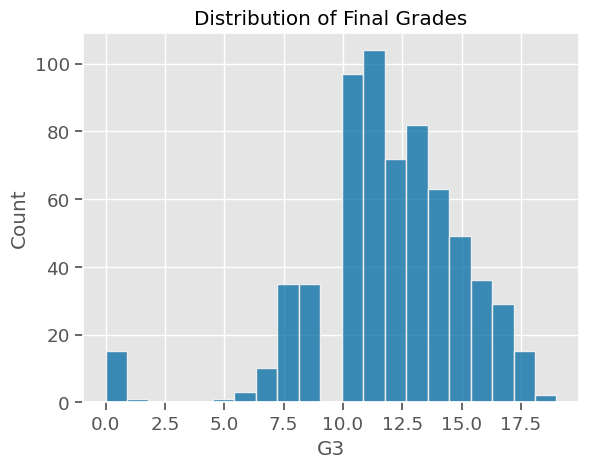

In [14]:
ax = sns.histplot(data=df,x='G3');
ax.set_title("Distribution of Final Grades")

**Observation:**
- Most students score between 10–15
- Distribution is slightly left-skewed
- A small group of students scored 0 — likely withdrew or failed entirely
- This confirms G3 is a suitable regression target

## 2. **Preprocessing**

### Selecting Features
We begin with **Use Case 1**: predicting G3 for 3rd-period students,
so we include G1 and G2 as features.

**Train Test Split**

In [15]:
# Make x and y variables
y = df['G3']
X = df.drop(columns=['G3'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (486, 32) | X_test: (163, 32)


### Categorical Pipeline

In [16]:
# make list of categorical columns
ohe_cols = X_train.select_dtypes('object').columns

# instantiate preprocessors
impute_constant = SimpleImputer(strategy='constant', fill_value= 'MISSING')
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# make pipeline for categorical data
ohe_pipe = make_pipeline(impute_constant, ohe_encoder)

# make tuple for column transformer
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

### Numeric Pipeline

In [17]:
# make list of numeric columns
num_cols = X_train.select_dtypes('number').columns

# instantiate preproecessors
impute_mean =(SimpleImputer(strategy='mean'))

# make pipeline for numerical data
num_pipe = make_pipeline(SimpleImputer(strategy='mean'))

# make tuple for column transfomer
num_tuple = ('numeric', num_pipe, num_cols)

### Preprocessor — ColumnTransformer

Note: `verbose_feature_names_out=False` keeps column names clean
without prefixes like `numeric__` or `categorical__`

In [18]:
# Create ColumnTransformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                  verbose_feature_names_out=False)

# Fit and get feature names
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'G1', 'G2', 'school_GP', 'school_MS', 'sex_F', 'sex_M',
       'address_R', 'address_U', 'famsize_GT3', 'famsize_LE3',
       'Pstatus_A', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_course', 'reason_home', 'reason_other',
       'reason_reputation', 'guardian_father', 'guardian_mother',
       'guardian_other', 'schoolsup_no', 'schoolsup_yes', 'famsup_no',
       'famsup_yes', 'paid_no', 'paid_yes', 'activities_no',
       'activities_yes', 'nursery_no', 'nursery_yes', 'higher_no',
       'higher_yes', 'internet_no', 'internet_yes', 'romantic_no',
       'romantic_yes'], dtype=object)

### Transform X_train and X_test into DataFrames

We convert the preprocessor output back to a DataFrame
to preserve column names and index alignment.

In [19]:
# Transform to DataFrames
X_train_tf = pd.DataFrame(preprocessor.transform(X_train),
                           columns=feature_names, index=X_train.index)

X_test_tf = pd.DataFrame(preprocessor.transform(X_test),
                          columns=feature_names, index=X_test.index)

X_train_tf.head(3)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,school_GP,school_MS,sex_F,sex_M,address_R,address_U,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,...,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,schoolsup_no,schoolsup_yes,famsup_no,famsup_yes,paid_no,paid_yes,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
54,15.0,3.0,3.0,1.0,1.0,0.0,5.0,3.0,4.0,4.0,4.0,1.0,0.0,13.0,12.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
208,16.0,2.0,3.0,2.0,1.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,0.0,13.0,12.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
23,16.0,2.0,2.0,2.0,2.0,0.0,5.0,4.0,4.0,2.0,4.0,5.0,2.0,10.0,10.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


### Verify Index Alignment

After transformation, we confirm that X and y
still correspond to the same students.

In [20]:
# Confirm index alignment between X_test and y_test
print('X_test_tf index:', X_test_tf.head(3).index.tolist())
print('y_test index:   ', y_test.head(3).index.tolist())

X_test_tf index: [104, 284, 579]
y_test index:    [104, 284, 579]


In [21]:
## confirm the first 3 rows index in y_test matches X_test_df
y_test.head(3)

,G3
104,16
284,6
579,9


## 3. Feature Importance

### What is Feature Importance?
Feature importance tells us how much each feature
contributed to the model's predictions.

- All values are between 0 and 1
- All values sum to 1 (100%)
- Higher value = More important feature

Tree-based models (Random Forest, Decision Trees)
calculate this automatically during training.

### Step 1 — Build & Evaluate the Model

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r_squared = r2_score(y_true, y_pred)
    if verbose == True:
        header = "-"*60
        print(header, f"Regression Metrics: {label}", header, sep='\n')
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
    if output_dict == True:
        metrics = {'Label':label, 'MAE':mae,
                   'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
        return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test,
                        verbose=True, output_frame=False):
    y_train_pred = reg.predict(X_train)
    results_train = regression_metrics(y_train, y_train_pred, verbose=verbose,
                                       output_dict=output_frame,
                                       label='Training Data')
    print()
    y_test_pred = reg.predict(X_test)
    results_test = regression_metrics(y_test, y_test_pred, verbose=verbose,
                                      output_dict=output_frame,
                                      label='Test Data')
    if output_frame:
        results_df = pd.DataFrame([results_train, results_test])
        results_df = results_df.set_index('Label')
        results_df.index.name = None
        return results_df.round(3)

In [23]:
# Fit Random Forest
reg = RandomForestRegressor(random_state=SEED)
reg.fit(X_train_tf, y_train)

# Evaluate
evaluate_regression(reg, X_train_tf, y_train, X_test_tf, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.322
- MSE = 0.267
- RMSE = 0.267
- R^2 = 0.975

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 0.803
- MSE = 1.581
- RMSE = 1.581
- R^2 = 0.828


### Step 2 — Extract Feature Importances

`.feature_importances_` is a NumPy array — one value per feature.
All values sum to 1.
We convert it to a Pandas Series to attach feature names.

Note: We use pd.Series (not DataFrame) because
feature importance is 1D — one column only.

In [24]:
# Obtain feature importances from the fit model
reg.feature_importances_

array([9.06096804e-03, 4.27750617e-03, 3.98699965e-03, 7.00472751e-03,
       2.25626018e-03, 3.51399028e-03, 2.49268280e-03, 7.28098375e-03,
       5.16832208e-03, 7.96493073e-03, 3.65255869e-03, 3.45093237e-03,
       2.12456262e-02, 1.43357641e-02, 8.49691456e-01, 1.50552537e-03,
       1.34049006e-03, 8.01336123e-04, 2.00642049e-03, 9.16339891e-04,
       1.07877854e-03, 7.07605663e-04, 9.56989326e-04, 5.25321529e-04,
       3.57271546e-04, 7.24549353e-04, 4.69078763e-04, 1.72276703e-03,
       7.87754005e-04, 4.04612977e-03, 4.95701770e-04, 6.32101752e-04,
       2.02437914e-03, 2.64153718e-03, 2.88623322e-04, 1.66038340e-03,
       1.49827250e-03, 7.13793226e-03, 1.32903677e-03, 2.40072554e-03,
       1.19251978e-03, 6.59015769e-04, 1.29186344e-03, 1.17453508e-03,
       2.87137667e-03, 2.08767090e-03, 4.90905227e-04, 2.05326973e-04,
       6.07999604e-04, 6.08562065e-04, 1.09193794e-03, 1.09819114e-03,
       3.43745866e-04, 3.14073124e-04, 3.66951986e-04, 5.29971880e-04,
      

In [25]:
# Raw importances (hard to read)
print('Number of importances:', len(reg.feature_importances_))
print('Number of features:   ', len(X_train_tf.columns))
print('Match?', len(reg.feature_importances_) == len(X_train_tf.columns))

Number of importances: 58
Number of features:    58
Match? True


In [26]:
# Saving the feature importances
importances = pd.Series(reg.feature_importances_, index= feature_names,
                       name='Feature Importance')
importances

,Feature Importance
age,0.009061
Medu,0.004278
Fedu,0.003987
traveltime,0.007005
studytime,0.002256
failures,0.003514
famrel,0.002493
freetime,0.007281
goout,0.005168
Dalc,0.007965


**I added `sort_values().head(10)` ← You'll see the 10 most important features sorted from largest to smallest — clearer and cleaner.**

In [27]:
# Convert to Series with feature names
importances = pd.Series(reg.feature_importances_,
                        index=feature_names,
                        name='Feature Importance')

# Verify sum = 1
print(f'Sum of importances: {importances.sum():.4f}')
importances.sort_values(ascending=False).head(10)

Sum of importances: 1.0000


,Feature Importance
G2,0.849691
absences,0.021246
G1,0.014336
age,0.009061
Dalc,0.007965
freetime,0.007281
reason_other,0.007138
traveltime,0.007005
goout,0.005168
Medu,0.004278


In [28]:
# verifying that feature importances sum to 1
importances.sum()

np.float64(0.9999999999999999)

## Visualizing Feature Importance

Plotting all 58 features at once is unreadable.
We will sort and plot only the top 10 most important features.

⚠️ Matplotlib quirk: bars are plotted in reverse order.
Solution: sort ascending + use .tail(10) instead of
sort descending + .head(10)

In [29]:
# Sort from smallest to largest
sorted_importance = importances.sort_values()
sorted_importance

,Feature Importance
paid_yes,0.000205
Fjob_teacher,0.000289
higher_yes,0.000314
higher_no,0.000344
Pstatus_T,0.000357
internet_no,0.000367
Mjob_health,0.000469
paid_no,0.000491
Fjob_at_home,0.000496
Pstatus_A,0.000525


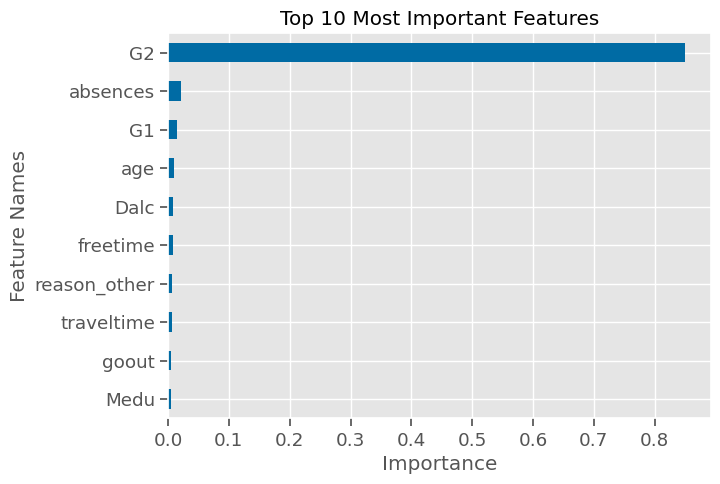

In [30]:
# Plot top 10 (tail because matplotlib reverses order)
ax = sorted_importance.tail(10).plot(kind='barh',
                                     figsize=(7,5))
ax.set(xlabel='Importance',
       ylabel='Feature Names',
       title='Top 10 Most Important Features')
plt.show()

### Saving the Figure

pandas .plot() returns an Axis, not a Figure.
Two ways to save the Figure:
1. ax.get_figure() — extract from axis
2. plt.gcf() — get current figure
Both produce the same result.

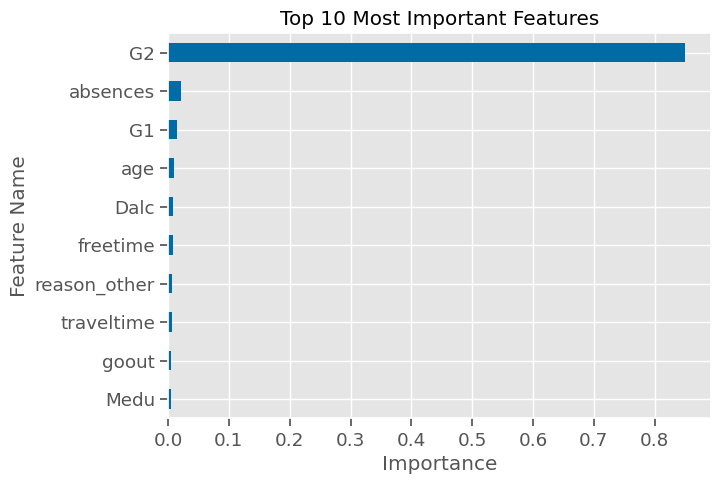

In [31]:
# Method 1: get_figure()
fig = ax.get_figure()

# Method 2: plt.gcf() - use in same cell as plot
ax = sorted_importance.tail(10).plot(kind='barh',
                                     figsize=(7,5),
                                     xlabel='Importance',
                                     ylabel='Feature Name',
                                     title='Top 10 Most Important Features')
fig = plt.gcf()

### Key Finding
G2 dominates with ~85% importance.
When G1 and G2 are included, the model relies
almost entirely on prior grades to predict G3.
This motivates building a second model without G1 and G2.

### Interpreting Feature Importance

**What it TELLS us:**
- G2 is by far the most important feature (~85%)
- Absences is the second most important
- G1, age, Dalc, freetime are somewhat important
- Everything else has minimal importance
- We could use these importances to select
  which features to keep in our model

**What it DOESN'T tell us ⚠️:**
- All values are positive — no +/- directionality
- We know THAT a feature is important
- But we DON'T KNOW the relationship direction:
  → Does more absences = higher G3?
  → Or more absences = lower G3?
  → We don't know from importance alone!

To understand direction → we need coefficients (next lesson)

## Feature Importance Functions

Instead of repeating the same code for every model,
we create reusable functions.

New concept: `feature_names=None` as default argument
→ If not provided, extract automatically from model
  using `model.feature_names_in_`

In [32]:
# The model memorizes feature names during training
reg.feature_names_in_

array(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'G1', 'G2', 'school_GP', 'school_MS', 'sex_F', 'sex_M',
       'address_R', 'address_U', 'famsize_GT3', 'famsize_LE3',
       'Pstatus_A', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_course', 'reason_home', 'reason_other',
       'reason_reputation', 'guardian_father', 'guardian_mother',
       'guardian_other', 'schoolsup_no', 'schoolsup_yes', 'famsup_no',
       'famsup_yes', 'paid_no', 'paid_yes', 'activities_no',
       'activities_yes', 'nursery_no', 'nursery_yes', 'higher_no',
       'higher_yes', 'internet_no', 'internet_yes', 'romantic_no',
       'romantic_yes'], dtype=object)

In [33]:
def get_importances(model, feature_names=None, name='Feature Importance',
                    sort=False, ascending=True):
    # Get feature names from model if not provided
    if feature_names == None:
        feature_names = model.feature_names_in_

    # Save as Series
    importances = pd.Series(model.feature_importances_,
                            index=feature_names, name=name)
    # Sort if requested
    if sort == True:
        importances = importances.sort_values(ascending=ascending)

    return importances

# Test the function
importances = get_importances(reg, sort=True, ascending=False)
importances

,Feature Importance
G2,0.849691
absences,0.021246
G1,0.014336
age,0.009061
Dalc,0.007965
freetime,0.007281
reason_other,0.007138
traveltime,0.007005
goout,0.005168
Medu,0.004278


<Axes: title={'center': 'All Features - Ranked by Importance'}, xlabel='Importance', ylabel='Feature Names'>

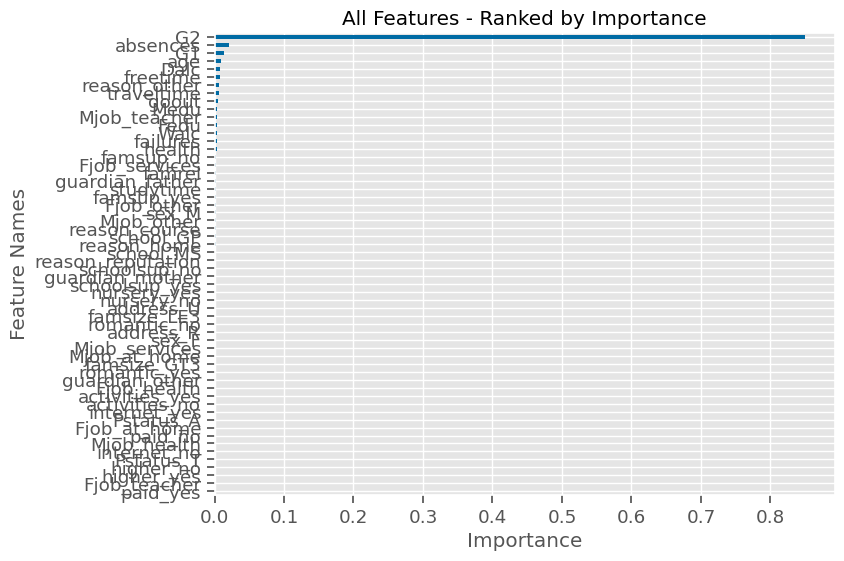

In [34]:
def plot_importance(importances, top_n=None, figsize=(8,6)):
    if top_n == None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
           ylabel='Feature Names',
           title=title)
    return ax

# Test - all features
plot_importance(importances)

<Axes: title={'center': 'Top 15 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

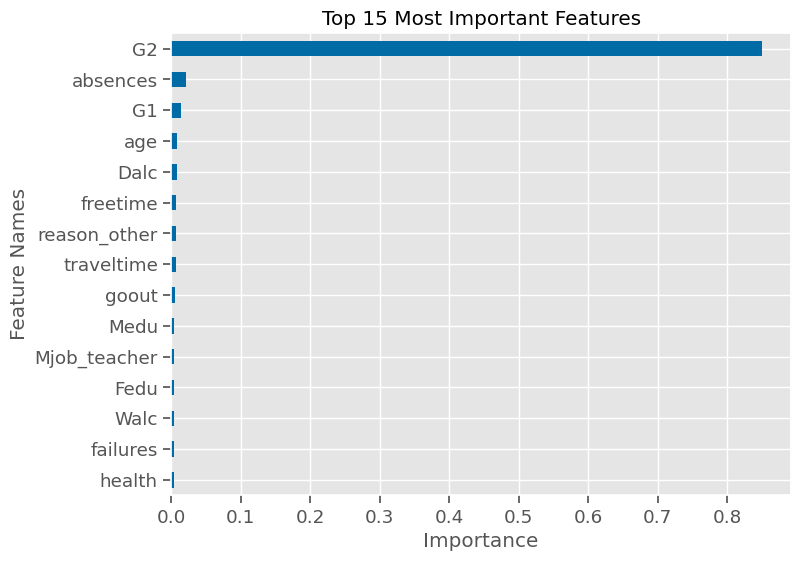

In [35]:
importances = get_importances(reg, sort=True, ascending=False,
                              name="RandomForest Importances")
plot_importance(importances, top_n=15)

### Remaking Our Model Using All 3 Functions

Now we can fit, evaluate, and visualize
in one efficient cell!

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.322
- MSE = 0.267
- RMSE = 0.267
- R^2 = 0.975

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 0.803
- MSE = 1.581
- RMSE = 1.581
- R^2 = 0.828


<Axes: title={'center': 'Top 10 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

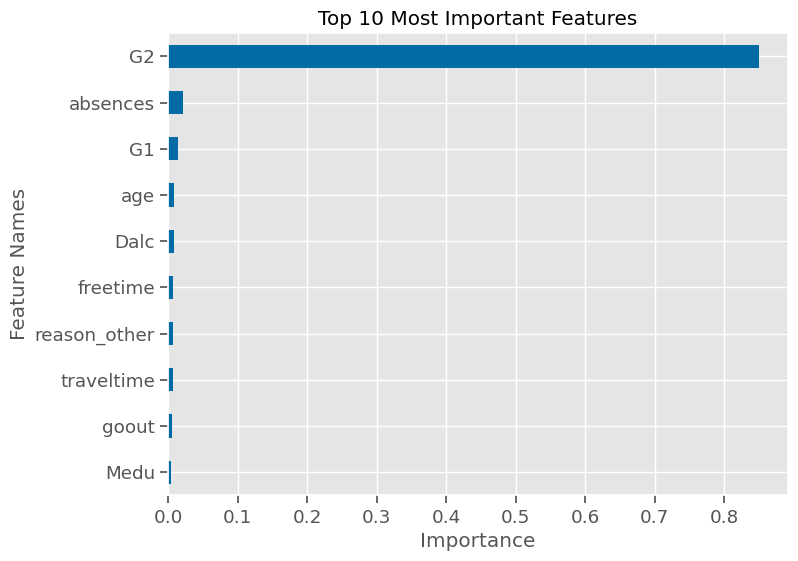

In [36]:
# Fit model
reg = RandomForestRegressor()
reg.fit(X_train_tf, y_train)

# Evaluate
evaluate_regression(reg, X_train_tf, y_train, X_test_tf, y_test)

# Feature Importance
importances = get_importances(reg)
plot_importance(importances, top_n=10)

## Exploring the Most Important Features

Feature importance tells us WHICH features matter.
EDA tells us HOW they relate to G3.

Top 4 features to explore:
1. G2 (~85%)
2. absences (~2%)
3. G1 (~1.4%)
4. age (~0.9%)

In [37]:
# Combine train and test for full visualization
plot_train = pd.concat([X_train_tf, y_train], axis=1)
plot_test = pd.concat([X_test_tf, y_test], axis=1)
plot_df = pd.concat([plot_train, plot_test])
print(f'plot_df shape: {plot_df.shape}')

plot_df shape: (649, 59)


### **G2 vs G3**
Using regplot() — plots scatter + linear best-fit line together.

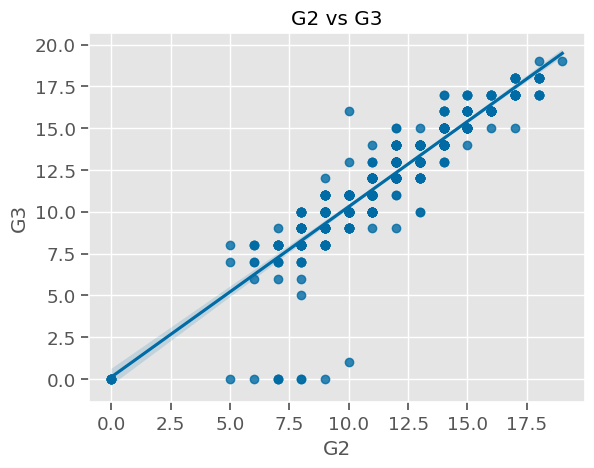

In [38]:
sns.regplot(data=plot_df, x='G2', y='G3')
plt.title('G2 vs G3')
plt.show()

Strong linear relationship — students who scored well
in period 2 consistently score well in period 3.

### **Absences vs G3**

When the relationship is non-linear, we use Lowess regression.

Lowess = Locally Weighted Smoothed Scatterplot
→ Creates a curve that adapts to the data in each region
→ More informative than a straight line for complex relationships

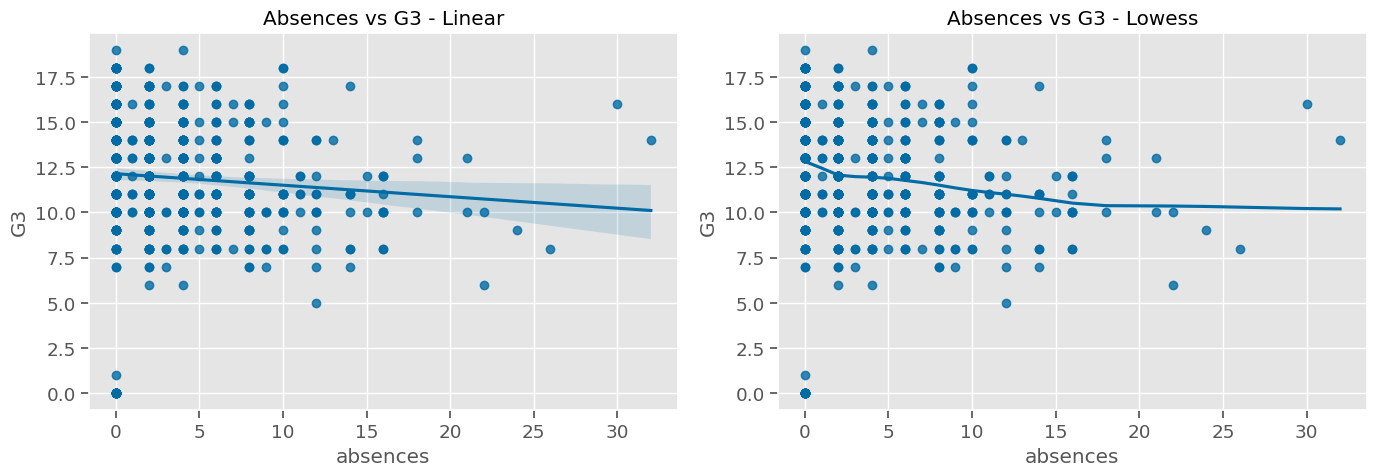

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=plot_df, x='absences', y='G3', ax=axes[0])
axes[0].set_title('Absences vs G3 - Linear')

sns.regplot(data=plot_df, x='absences', y='G3',
            lowess=True, ax=axes[1])
axes[1].set_title('Absences vs G3 - Lowess')

plt.tight_layout()
plt.show()

Absences show a non-linear relationship:
- 0–16 absences: G3 gradually decreases
- 16+ absences: G3 levels off

### **G1 vs G3**

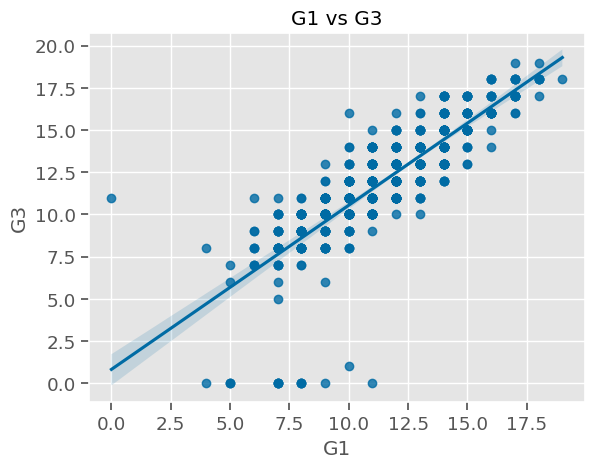

In [40]:
sns.regplot(data=plot_df, x='G1', y='G3')
plt.title('G1 vs G3')
plt.show()

### **Age vs G3**

Age shows a complex relationship — we use multiple visualizations:
1. regplot with lowess
2. barplot (average G3 per age group)
3. stripplot + barplot combined (advanced technique)

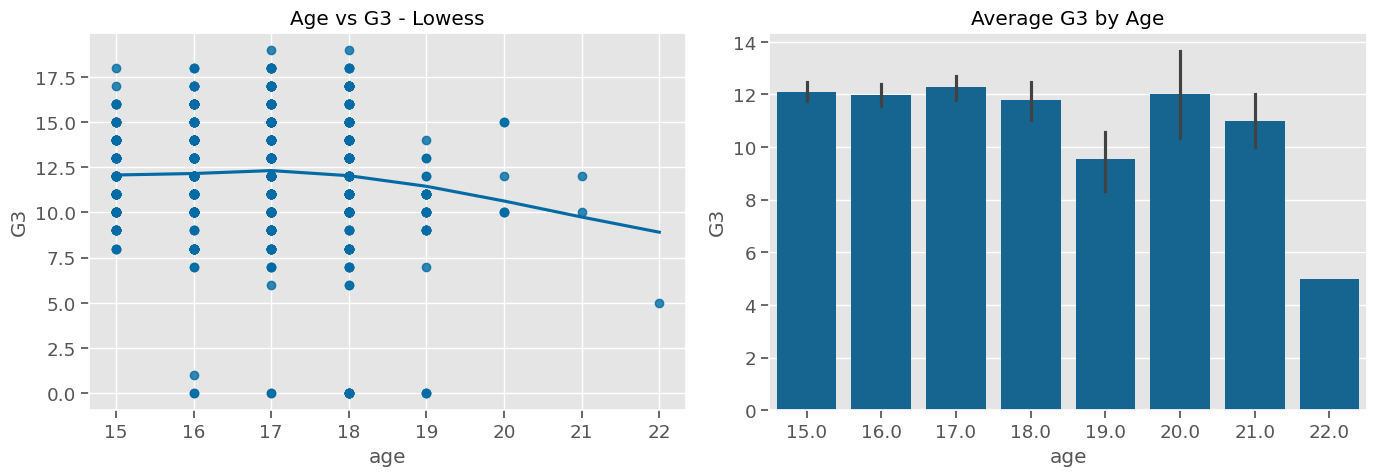

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=plot_df, x='age', y='G3',
            lowess=True, ax=axes[0])
axes[0].set_title('Age vs G3 - Lowess')

sns.barplot(data=plot_df, x='age', y='G3', ax=axes[1])
axes[1].set_title('Average G3 by Age')

plt.tight_layout()
plt.show()

### Age vs G3 — Strip + Bar Plot (Advanced)

stripplot = scatterplot where points don't overlap
→ Combined with barplot to show both:
   - Individual students (stripplot)
   - Average grade per age (barplot)

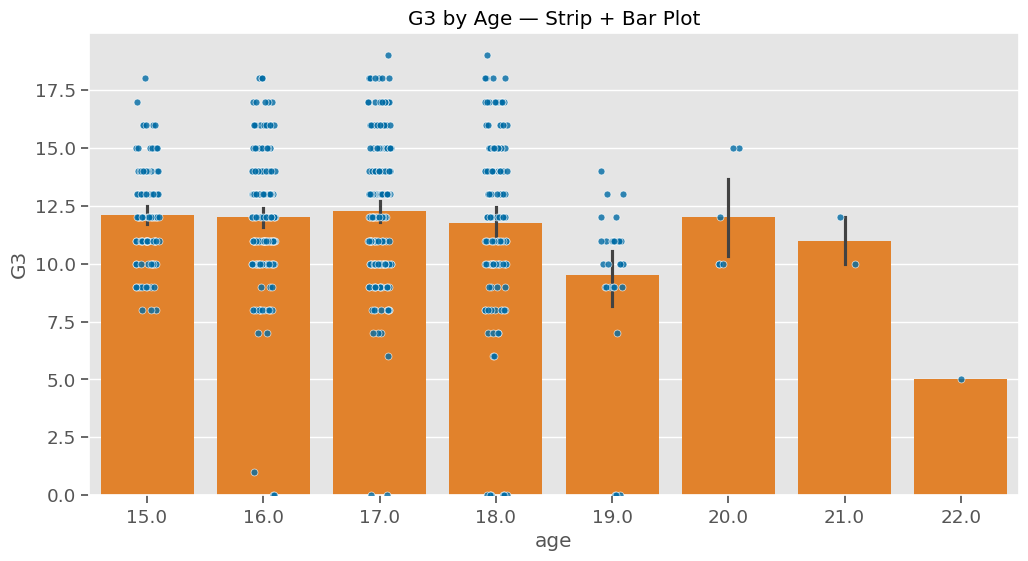

In [42]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_df, x='age', y='G3',
              size=5, edgecolor='white',
              linewidth=0.5, alpha=.8)
sns.barplot(data=plot_df, x='age', y='G3')
plt.title('G3 by Age — Strip + Bar Plot')
plt.show()

### Key Finding
Older students tend to perform worse in G3.
Possible reason: they may have been held back
or started school at a later age.

## Plotting the Decision Tree

We can extract a single tree from our Random Forest
and visualize its decision pathway.
This helps us see HOW the model makes decisions.

In [43]:
# Extract first tree from the forest
example_tree = reg.estimators_[0]

# Evaluate single tree performance
evaluate_regression(example_tree, X_train_tf, y_train, X_test_tf, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.426
- MSE = 1.340
- RMSE = 1.340
- R^2 = 0.876

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 0.939
- MSE = 2.620
- RMSE = 2.620
- R^2 = 0.715


In [44]:
# How deep did the tree grow?
print(f'Tree Depth: {example_tree.get_depth()}')
# Large depth = hard to visualize fully

Tree Depth: 12


The tree is 12 levels deep — too large to visualize fully.
We will limit visualization to max_depth=4 (first 4 levels only).

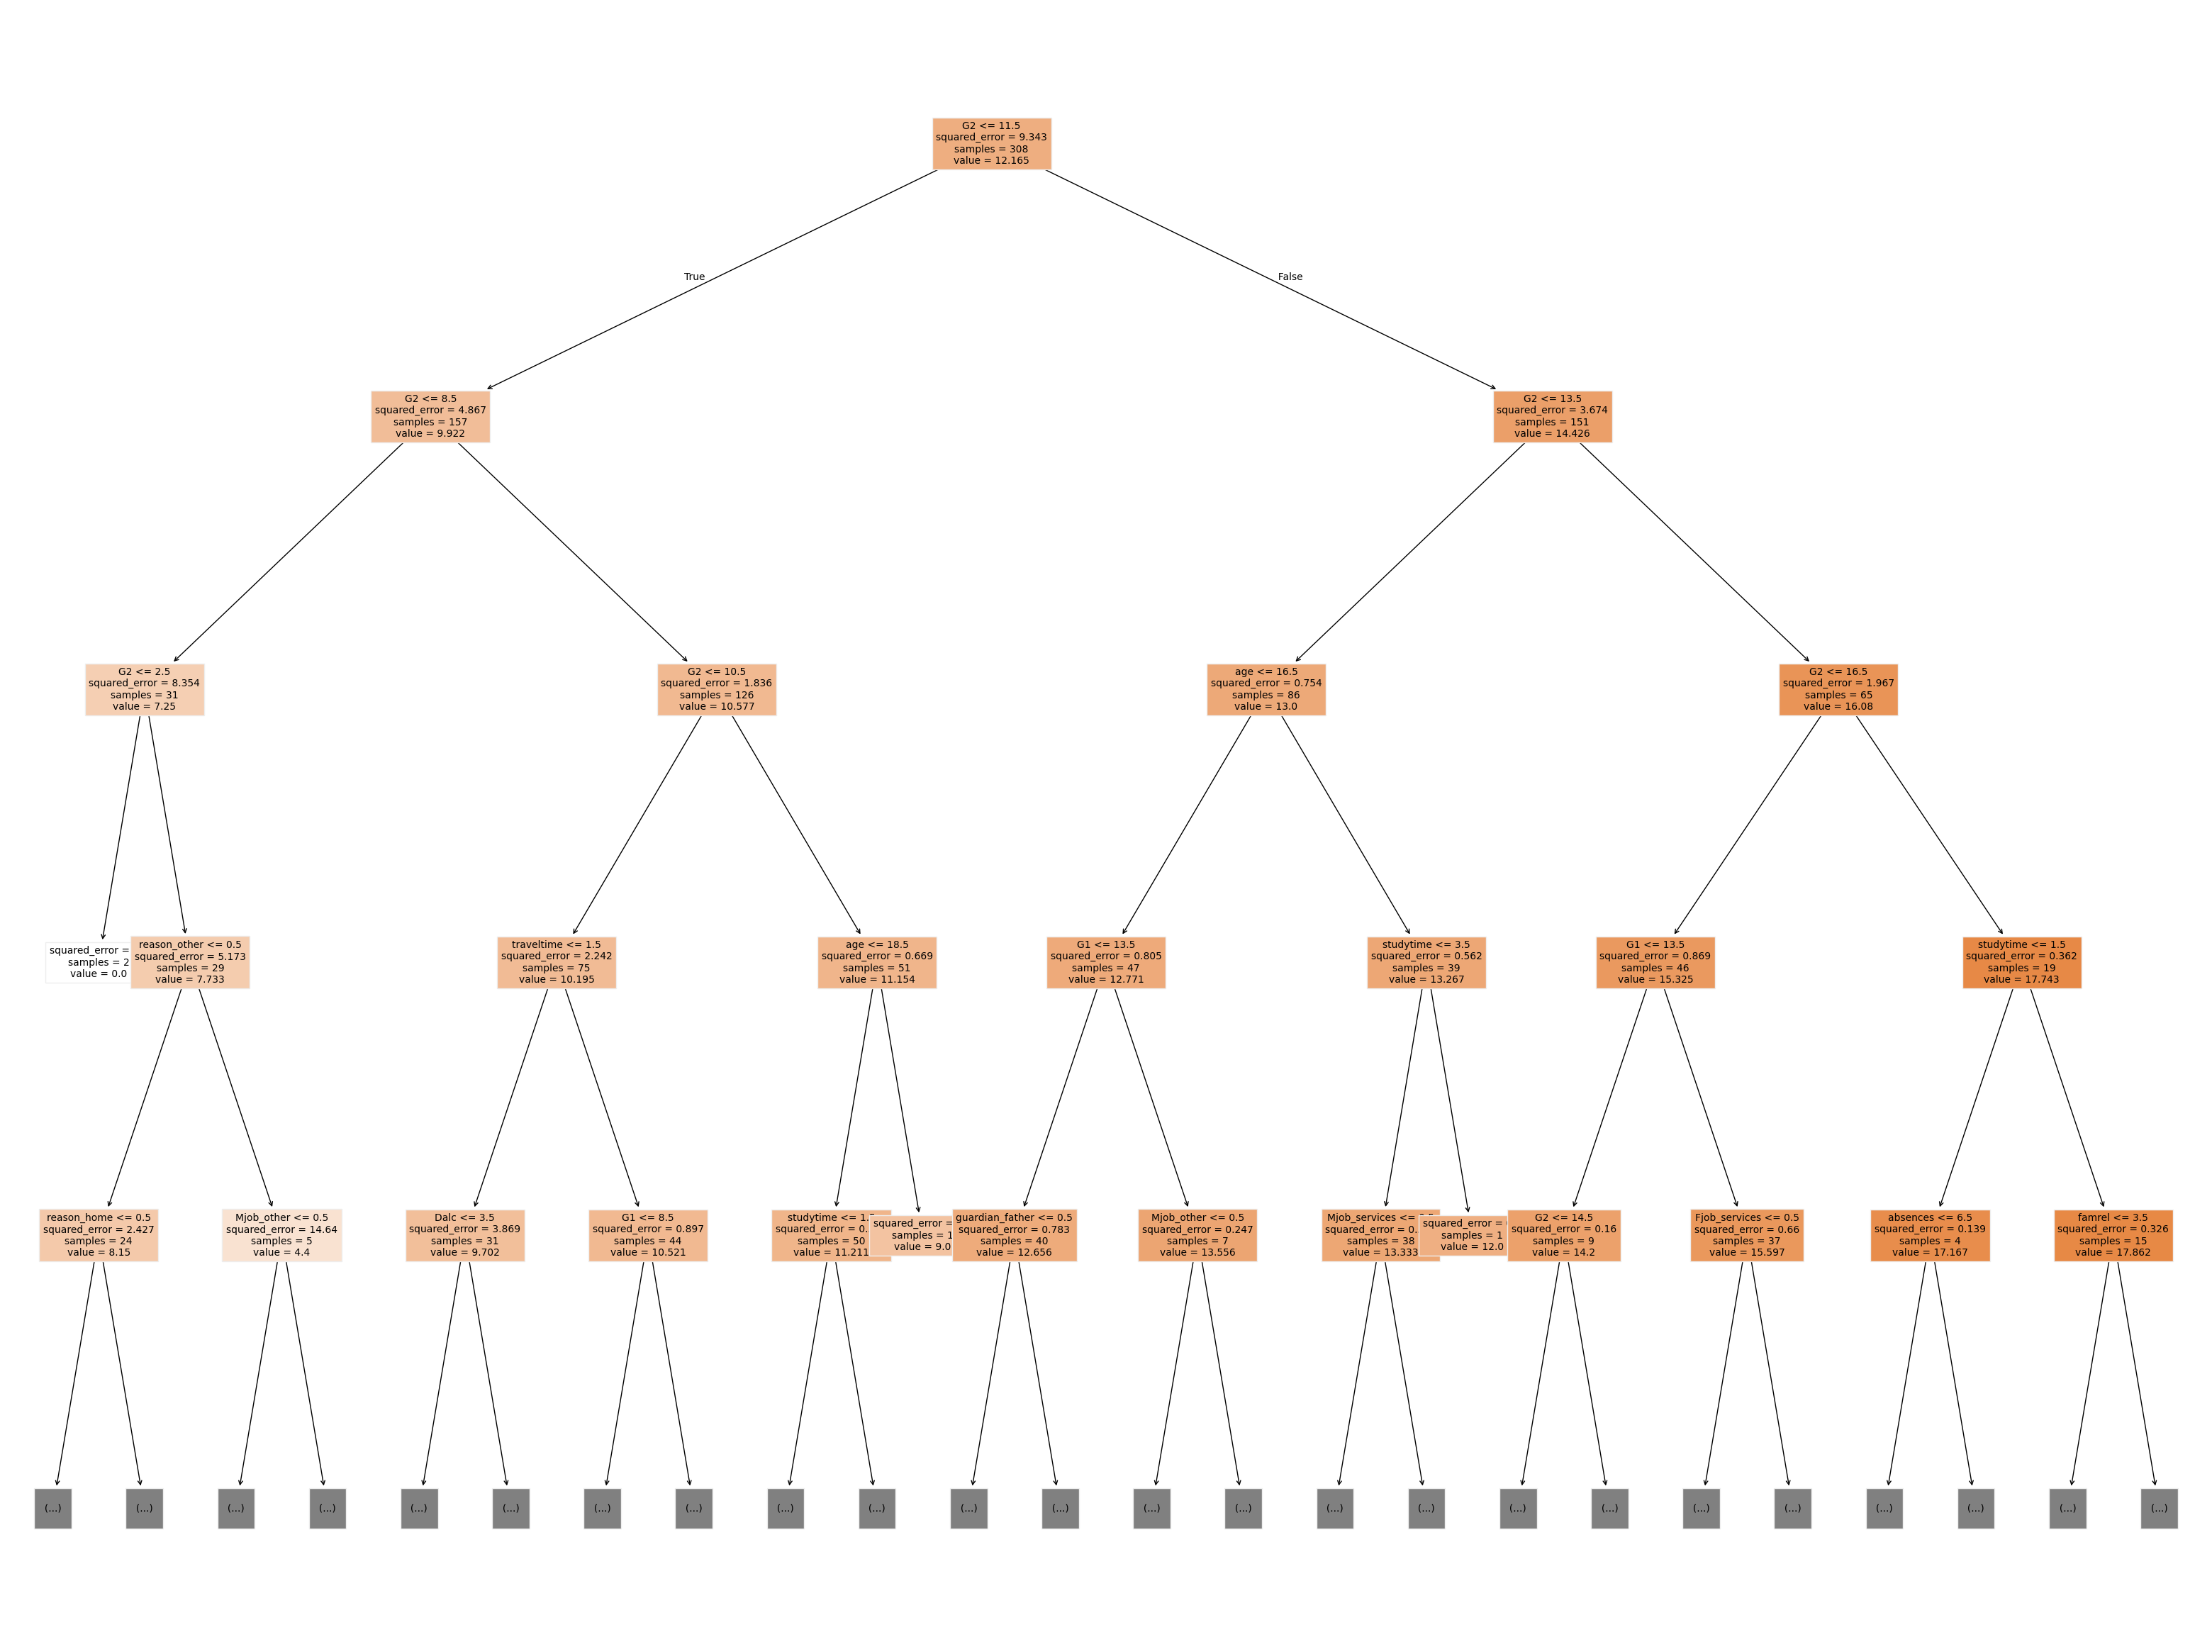

In [45]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(40, 30))
plot_tree(example_tree, max_depth=4, filled=True,
          feature_names=feature_names, ax=ax, fontsize=10)
plt.show()

Notice: G2 appears repeatedly in the early splits.
This confirms that G2 is the most important feature —
the model uses it most often to separate students.

## Task B — Modeling Without G1 & G2

Our stakeholders want to identify at-risk students
BEFORE period 1 and 2 grades are available.

Solution: Remove G1 and G2 from features entirely.
Trade-off: Less accurate model, but more useful
for early intervention.

In [46]:
# Drop prior grade features
drop_cols = ['G1', 'G2']
X_train_B = X_train_tf.drop(columns=drop_cols)
X_test_B = X_test_tf.drop(columns=drop_cols)
feature_names_B = X_train_B.columns

print(f'Features remaining: {X_train_B.shape[1]}')
X_train_B.head(3)

Features remaining: 56


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,school_GP,school_MS,sex_F,sex_M,address_R,address_U,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,Mjob_at_home,Mjob_health,...,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,schoolsup_no,schoolsup_yes,famsup_no,famsup_yes,paid_no,paid_yes,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
54,15.0,3.0,3.0,1.0,1.0,0.0,5.0,3.0,4.0,4.0,4.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
208,16.0,2.0,3.0,2.0,1.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
23,16.0,2.0,2.0,2.0,2.0,0.0,5.0,4.0,4.0,2.0,4.0,5.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.781
- MSE = 1.171
- RMSE = 1.171
- R^2 = 0.892

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.724
- MSE = 5.932
- RMSE = 5.932
- R^2 = 0.354


<Axes: title={'center': 'Top 15 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

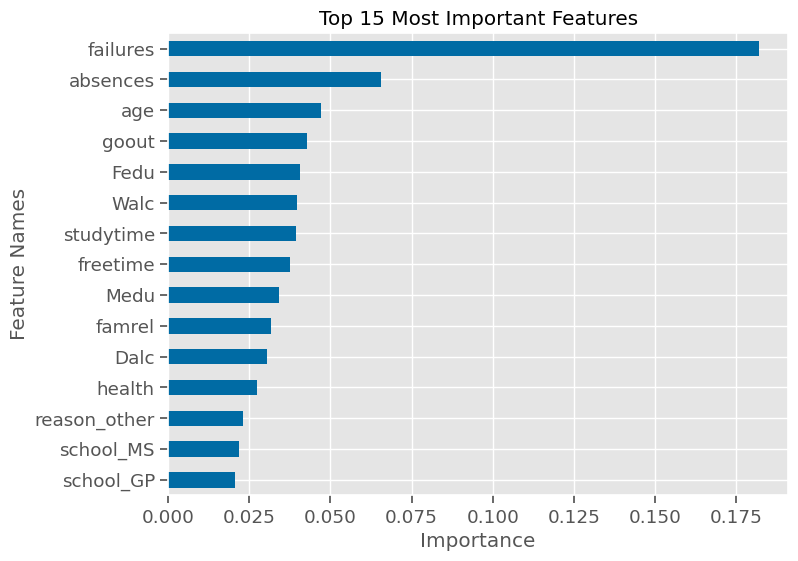

In [47]:
reg_B = RandomForestRegressor(random_state=SEED)
reg_B.fit(X_train_B, y_train)

evaluate_regression(reg_B, X_train_B, y_train, X_test_B, y_test)

importances = get_importances(reg_B, sort=True, ascending=False)
plot_importance(importances, top_n=15)

### Model B Results

| | Model A (with G1,G2) | Model B (without) |
|--|--|--|
| R² Test | 0.828 | 0.354 |

Performance dropped significantly — expected!
G2 alone was responsible for 85% of predictions.

Benefit: Model B now uses real student characteristics
(failures, studytime, etc.) — more actionable for schools.

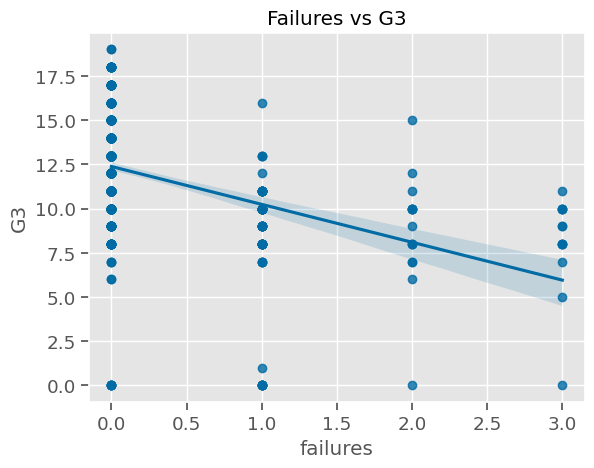

In [48]:
sns.regplot(data=plot_df, x='failures', y='G3')
plt.title('Failures vs G3')
plt.show()

### ⚠️ Caveat: Built-in Feature Importance Bias

Built-in importance is biased:
- Favors features with MANY unique values (age, absences)
- Undervalues One-Hot Encoded features (only 0 or 1)

Solution → Permutation Importance (next lesson)
This method removes the bias by testing each feature
directly on model performance.

#**Permutation Importance**

## Permutation Importance

Unlike built-in importance, permutation importance
works by shuffling each feature's values randomly
and measuring how much the model's performance drops.

Key advantages:
- No bias towards features with many unique values
- Works with any model (model agnostic)
- Fair evaluation of One-Hot Encoded features

Note: Negative values mean the feature was
actually hurting the model's performance.

In [49]:
#  حساب الـ Permutation Importance
from sklearn.inspection import permutation_importance

r = permutation_importance(reg_B, X_test_B, y_test,
                           n_repeats=5, random_state=SEED)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [50]:
# تحويل النتائج لـ Series عشان نقدر نشتغل عليها
permutation_importances = pd.Series(r['importances_mean'],
                                    index=X_test_B.columns,
                                    name='permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
failures,0.357428
studytime,0.045001
absences,0.035727
Dalc,0.024777
goout,0.020265
age,0.019417
health,0.017610
Medu,0.015610
higher_no,0.014927
higher_yes,0.012659


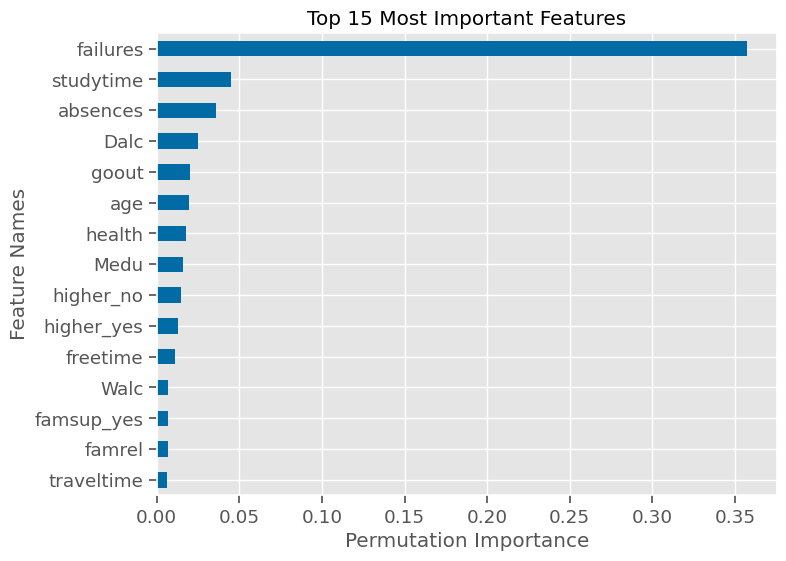

In [51]:
# رسم أهم 15 feature
ax = plot_importance(permutation_importances, top_n=15)
ax.set(xlabel='Permutation Importance')
plt.show()

**يعني: الطالب اللي رسب قبل = أكثر عرضة لرسوب G3**

### Color Coding for Comparison

We highlight the top 5 features from built-in importance in green
to visually compare which features both methods agree on.

In [52]:
#جيب أهم 5 features من الـ built-in importance
highlight_feats = importances.sort_values(ascending=True).tail(5).index
highlight_feats

Index(['Fedu', 'goout', 'age', 'absences', 'failures'], dtype='object')

In [53]:
# عمل dictionary للألوان (أخضر للمهم، أزرق للباقي)
colors_dict = {}
for col in importances.index:
    if col in highlight_feats:
        colors_dict[col] = 'green'
    else:
        colors_dict[col] = '#006ba4'
colors_dict

{'failures': 'green',
 'absences': 'green',
 'age': 'green',
 'goout': 'green',
 'Fedu': 'green',
 'Walc': '#006ba4',
 'studytime': '#006ba4',
 'freetime': '#006ba4',
 'Medu': '#006ba4',
 'famrel': '#006ba4',
 'Dalc': '#006ba4',
 'health': '#006ba4',
 'reason_other': '#006ba4',
 'school_MS': '#006ba4',
 'school_GP': '#006ba4',
 'traveltime': '#006ba4',
 'higher_no': '#006ba4',
 'Mjob_teacher': '#006ba4',
 'higher_yes': '#006ba4',
 'reason_home': '#006ba4',
 'schoolsup_no': '#006ba4',
 'reason_reputation': '#006ba4',
 'Fjob_teacher': '#006ba4',
 'schoolsup_yes': '#006ba4',
 'famsup_no': '#006ba4',
 'Fjob_services': '#006ba4',
 'Mjob_at_home': '#006ba4',
 'activities_yes': '#006ba4',
 'Mjob_other': '#006ba4',
 'reason_course': '#006ba4',
 'famsup_yes': '#006ba4',
 'Fjob_other': '#006ba4',
 'sex_M': '#006ba4',
 'activities_no': '#006ba4',
 'famsize_LE3': '#006ba4',
 'sex_F': '#006ba4',
 'Mjob_services': '#006ba4',
 'romantic_no': '#006ba4',
 'guardian_mother': '#006ba4',
 'nursery_yes': '

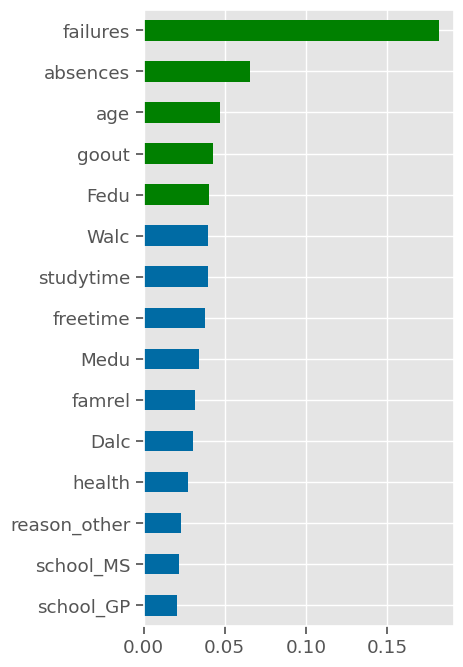

In [54]:
#  رسم الـ built-in importance مع الألوان
plot_vals = importances.sort_values().tail(15)
plot_vals.plot(kind='barh',
               color=plot_vals.index.map(colors_dict),
               figsize=(4, 8))
plt.show()

In [55]:
#  دالة get_color_dict لإعادة الاستخدام
def get_color_dict(importances, color_rest='#006ba4',
                   color_top='green', top_n=7):
    highlight_feats = importances.sort_values(ascending=True).tail(top_n).index
    colors_dict = {col: color_top if col in highlight_feats
                   else color_rest for col in importances.index}
    return colors_dict

colors_top7 = get_color_dict(importances, top_n=7)
colors_top7

{'failures': 'green',
 'absences': 'green',
 'age': 'green',
 'goout': 'green',
 'Fedu': 'green',
 'Walc': 'green',
 'studytime': 'green',
 'freetime': '#006ba4',
 'Medu': '#006ba4',
 'famrel': '#006ba4',
 'Dalc': '#006ba4',
 'health': '#006ba4',
 'reason_other': '#006ba4',
 'school_MS': '#006ba4',
 'school_GP': '#006ba4',
 'traveltime': '#006ba4',
 'higher_no': '#006ba4',
 'Mjob_teacher': '#006ba4',
 'higher_yes': '#006ba4',
 'reason_home': '#006ba4',
 'schoolsup_no': '#006ba4',
 'reason_reputation': '#006ba4',
 'Fjob_teacher': '#006ba4',
 'schoolsup_yes': '#006ba4',
 'famsup_no': '#006ba4',
 'Fjob_services': '#006ba4',
 'Mjob_at_home': '#006ba4',
 'activities_yes': '#006ba4',
 'Mjob_other': '#006ba4',
 'reason_course': '#006ba4',
 'famsup_yes': '#006ba4',
 'Fjob_other': '#006ba4',
 'sex_M': '#006ba4',
 'activities_no': '#006ba4',
 'famsize_LE3': '#006ba4',
 'sex_F': '#006ba4',
 'Mjob_services': '#006ba4',
 'romantic_no': '#006ba4',
 'guardian_mother': '#006ba4',
 'nursery_yes': '#006

### plot_importance_color Function

Updated plotting function that accepts a color dictionary.
- color_dict=None → default blue for all bars
- color_dict provided → colors applied per feature

In [56]:
def plot_importance_color(importances, top_n=None, figsize=(8,6),
                          color_dict=None):
    if top_n == None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)
    else:
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    ax.set(xlabel='Importance', ylabel='Feature Names', title=title)
    return ax

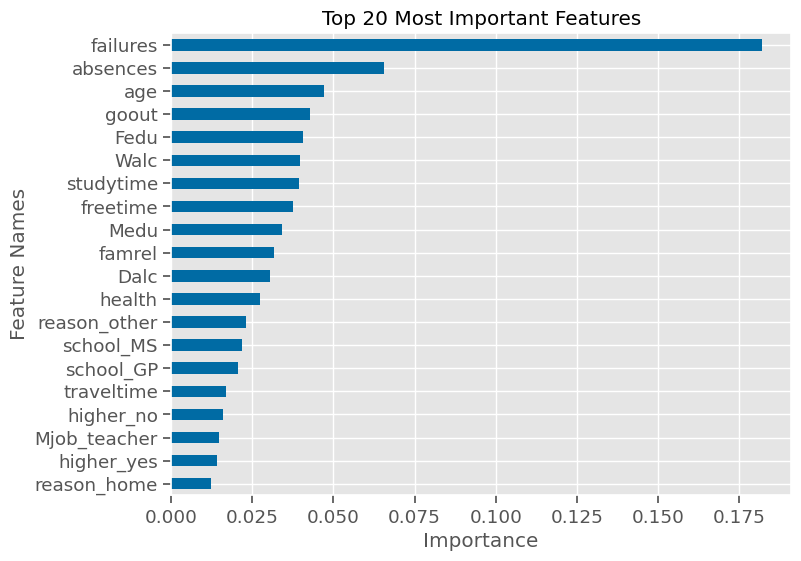

In [57]:
#  تجربة الدالة بدون ألوان
plot_importance_color(importances, color_dict=None, top_n=20)
plt.show()

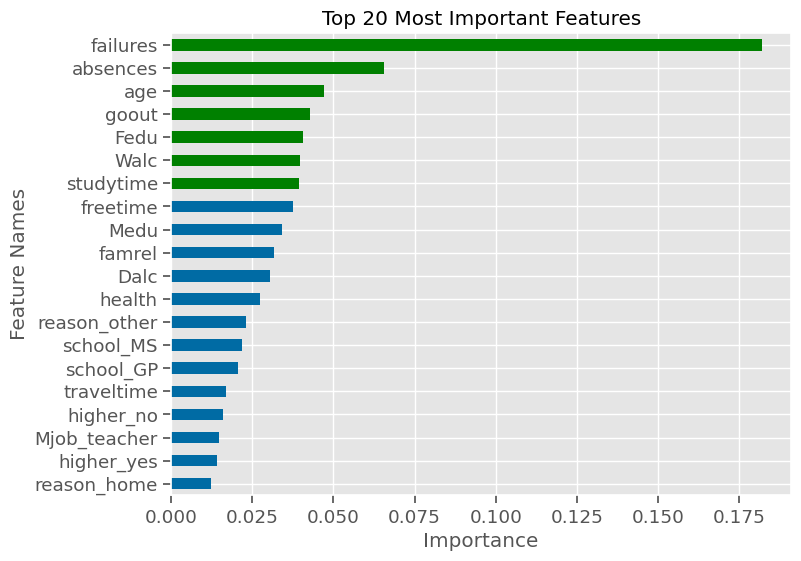

In [58]:
#  تجربة الدالة مع الألوان
plot_importance_color(importances, color_dict=colors_top7, top_n=20)
plt.show()

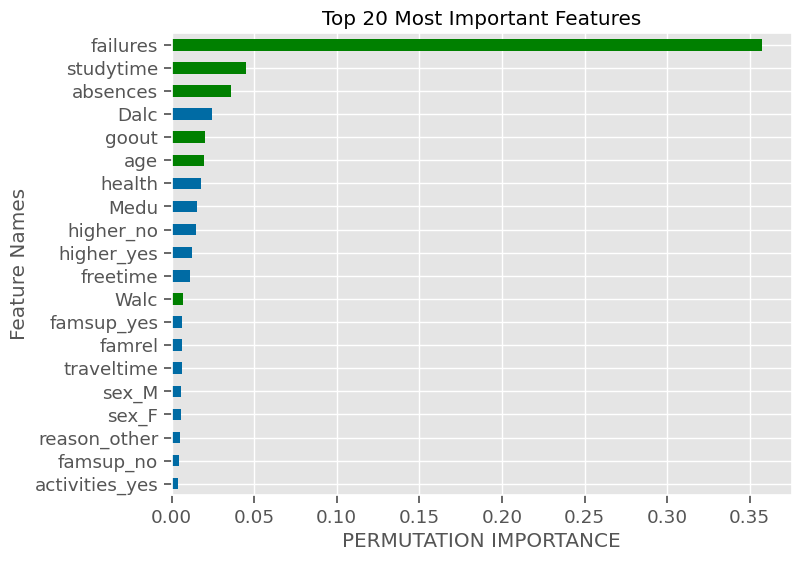

In [59]:
# رسم الـ Permutation مع الألوان للمقارنة
ax = plot_importance_color(permutation_importances,
                           color_dict=colors_top7, top_n=20)
ax.set_xlabel("PERMUTATION IMPORTANCE")
plt.show()

### Side-by-Side Comparison

New: ax argument in plotting functions.
- ax=None → pandas creates a new figure automatically
- ax=axes[0] → plot draws onto a specific subplot

This allows placing two plots side by side.

In [60]:
# دالة الرسم مع دعم الـ subplots
def plot_importance_color_ax(importances, top_n=None, figsize=(8,6),
                             color_dict=None, ax=None):
    if top_n == None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors, ax=ax)
    else:
        ax = plot_vals.plot(kind='barh', figsize=figsize, ax=ax)

    ax.set(xlabel='Importance', ylabel='Feature Names', title=title)
    return ax

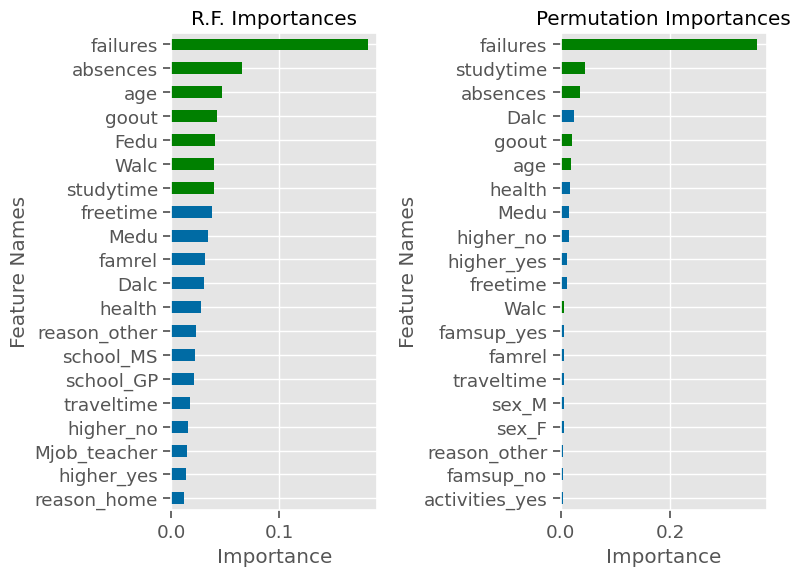

In [61]:
#  رسم المقارنة جنب بجنب
fig, axes = plt.subplots(ncols=2, figsize=(20, 8))
n = 20

plot_importance_color_ax(importances, top_n=n,
                         ax=axes[0], color_dict=colors_top7)
plot_importance_color_ax(permutation_importances, top_n=n,
                         ax=axes[1], color_dict=colors_top7)

axes[0].set(title='R.F. Importances')
axes[1].set(title='Permutation Importances')
fig.tight_layout()
plt.show()

**Permutation وجد higher_no بالـ top 10**

**Built-in ما وجدها — بسبب الـ bias ضد binary features**

### Key Findings — Built-in vs Permutation

| | Built-in | Permutation |
|--|--|--|
| Most Important | failures ✅ | failures ✅ |
| Bias | Favors continuous | No bias ✅ |
| Categorical in top 10? | No ❌ | Yes (higher_no) ✅ |

Both methods agree on failures as #1.
Permutation found higher_no important —
built-in missed it due to binary feature bias.

### EDA — Categorical Features

Now that permutation importance revealed categorical
features matter, we visualize them using the original
DataFrame (before One-Hot Encoding).

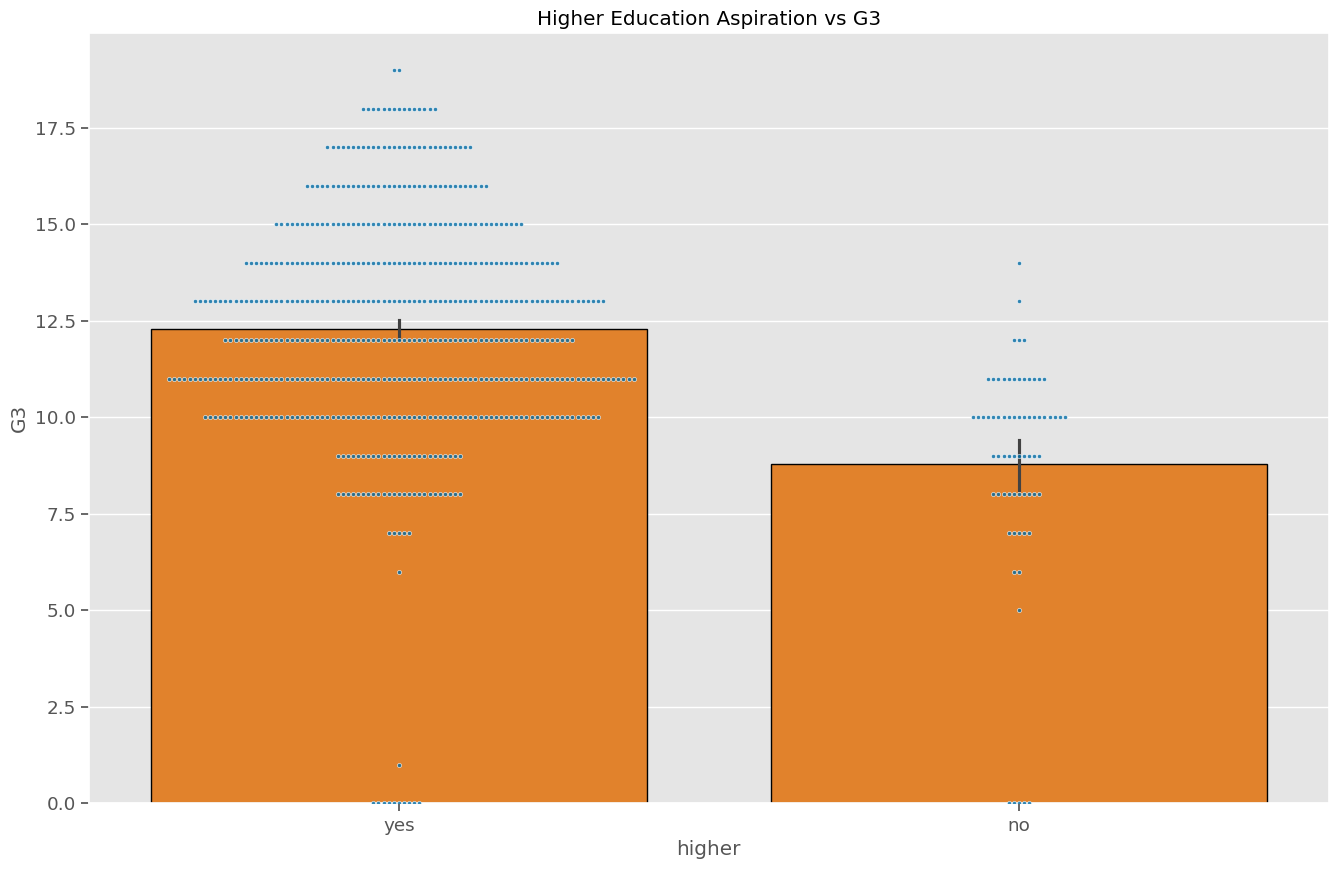

In [62]:
# رسم higher مقابل G3 بـ swarmplot + barplot

plt.figure(figsize=(16, 10))
sns.swarmplot(data=df, x='higher', y='G3',
              size=3, edgecolor='white',
              linewidth=0.5, alpha=.8)
sns.barplot(data=df, x='higher', y='G3',
            edgecolor='black', linewidth=1)
plt.title('Higher Education Aspiration vs G3')
plt.show()

### Advantages & Disadvantages

✅ Advantages:
- Model agnostic
- No bias towards continuous features
- Fair for One-Hot Encoded features

❌ Disadvantages:
- Doesn't tell us direction of relationship
- Computationally slower than built-in

→ Next: Coefficients to understand direction

### Key Findings — Built-in vs Permutation Importance

| | Built-in | Permutation |
|--|--|--|
| Speed | Fast ✅ | Slower ❌ |
| Accuracy | Biased ❌ | More accurate ✅ |
| Fair with OHE features? | No ❌ | Yes ✅ |
| Shows direction? | No ❌ | No ❌ |

**Features both methods agree on:**
failures, absences, goout, age ✅

**Built-in only:**
Fedu, Walc
→ Likely overvalued due to bias towards continuous features

**Permutation only:**
studytime, Dalc, higher_no
→ More reliable — no bias
→ higher_no is a binary feature that Built-in undervalued

**Conclusion:**
Permutation Importance is more trustworthy,
especially for One-Hot Encoded features.
However, neither method tells us the DIRECTION
of each feature's effect on G3.
→ Next: Coefficients to understand direction

#**Linear Regression Coefficients**

## Linear Regression Coefficients

Coefficients tell us:
- WHICH features matter (like importance)
- HOW they affect G3 — positive or negative direction

Three rules for interpretation:
1. Numeric (not scaled): +1 unit → X change in G3
2. OHE feature: belonging to this category → X change in G3
3. Numeric (scaled): +1 std → X change in G3

In [63]:
# Fitting linear regression - first attempt
# بنبني أول نموذج ونشوف المشكلة
lin_reg = LinearRegression()
lin_reg.fit(X_train_B, y_train)
evaluate_regression(lin_reg, X_train_B, y_train, X_test_B, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.961
- MSE = 7.047
- RMSE = 7.047
- R^2 = 0.350

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.684
- MSE = 5.979
- RMSE = 5.979
- R^2 = 0.349


In [64]:
# بنجيب الـ coefficients ونشوف الأرقام الضخمة
# Coefficients - notice the huge numbers!
# Obtain coefficients from linear regression model
lin_reg.coef_

array([ 0.17669951,  0.08757586,  0.2129001 ,  0.25028098,  0.46243221,
       -1.29454708,  0.15857916, -0.23470034,  0.00522418, -0.21265772,
       -0.07126103, -0.1230609 , -0.02937118,  0.73033737, -0.73033737,
        0.32917063, -0.32917063, -0.11592933,  0.11592933, -0.24652249,
        0.24652249, -0.13728522,  0.13728522, -0.3244093 ,  0.59467942,
       -0.22708791,  0.03129094, -0.07447314,  0.27985746, -0.8753169 ,
       -0.10445651, -0.52846216,  1.22837812,  0.04335648,  0.1587911 ,
       -0.1716682 , -0.03047937,  0.13657265, -0.24288451,  0.10631186,
        0.65748346, -0.65748346,  0.00493665, -0.00493665,  0.2400509 ,
       -0.2400509 , -0.14324611,  0.14324611,  0.19854395, -0.19854395,
       -0.84743004,  0.84743004, -0.15108447,  0.15108447,  0.20757778,
       -0.20757778])

In [65]:
# Checking the number of coeffs matches the # of feature names
print(len(lin_reg.coef_))
len(feature_names_B)

56


56

### ⚠️ Problem: Multicollinearity

Coefficients are in the billions — makes no sense for G3 (0-20)!

**Why?** OneHotEncoder created redundant columns:
- paid_yes + paid_no → if one = 1, the other must = 0
- These perfectly correlated columns confuse Linear Regression

**Solution 1:** drop='if_binary' → removes one column
for binary features only

**Solution 2:** drop='first' → removes first category
for ALL features (complete fix)

In [66]:
#  إعادة بناء الداتا مع drop='if_binary'
# Rebuild X and y
y = df['G3'].copy()
X = df.drop(columns=['G1', 'G2', 'G3'])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)

# Categorical pipeline with drop='if_binary'
ohe_cols = X_train.select_dtypes('object').columns
impute_constant = SimpleImputer(strategy='constant', fill_value='MISSING')
ohe_encoder = OneHotEncoder(drop='if_binary', sparse_output=False)
ohe_pipe = make_pipeline(impute_constant, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

num_cols = X_train.select_dtypes('number').columns
num_pipe = make_pipeline(SimpleImputer(strategy='mean'))
num_tuple = ('numeric', num_pipe, num_cols)

preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                  verbose_feature_names_out=False)
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(preprocessor.transform(X_train),
                           columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(preprocessor.transform(X_test),
                          columns=feature_names, index=X_test.index)
X_test_df.head(3)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
104,15.0,3.0,4.0,1.0,2.0,0.0,5.0,4.0,4.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
284,18.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,5.0,2.0,5.0,5.0,4.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
579,18.0,1.0,3.0,1.0,1.0,0.0,4.0,3.0,3.0,2.0,3.0,3.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


drop='if_binary' fixed binary features (school, sex, romantic...)

BUT features with more than 2 categories (Mjob, Fjob, reason)

still have huge coefficients → need drop='first'

In [67]:
# إعادة البناء مع drop='first'
# Complete fix with drop='first'
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False)
ohe_pipe = make_pipeline(impute_constant, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                  verbose_feature_names_out=False)
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(preprocessor.transform(X_train),
                           columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(preprocessor.transform(X_test),
                          columns=feature_names, index=X_test.index)

# Refit model
lin_reg = LinearRegression()
lin_reg.fit(X_train_df, y_train)
evaluate_regression(lin_reg, X_train_df, y_train, X_test_df, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.961
- MSE = 7.047
- RMSE = 7.047
- R^2 = 0.350

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.684
- MSE = 5.979
- RMSE = 5.979
- R^2 = 0.349


In [68]:
# حفظ الـ coefficients وعرضها
# Save coefficients as Series
coeffs = pd.Series(lin_reg.coef_, index=lin_reg.feature_names_in_)
coeffs['intercept'] = lin_reg.intercept_
coeffs

,0
age,0.176700
Medu,0.087576
Fedu,0.212900
traveltime,0.250281
studytime,0.462432
failures,-1.294547
famrel,0.158579
freetime,-0.234700
goout,0.005224
Dalc,-0.212658


### 📊 Linear Regression Coefficients Interpretation

The following table explains how each feature impacts the final grade (**G3**) based on the model coefficients:


| Feature | Coefficient | Impact | Brief Interpretation |
|:---|:---:|:---:|:---|
| **failures** | `-1.29` | 🔻 Strong Negative | Each additional failure drastically **decreases** the grade by 1.29 points. |
| **school_MS** | `-1.46` | 🔻 Strong Negative | Students at "MS" school tend to have **lower** grades than those at "GP". |
| **sex_M** | `-0.66` | 🔻 Negative | Male students show a **decrease** of 0.66 in their predicted grade. |
| **studytime** | `+0.46` | 🟢 Positive | Every extra unit of study time **increases** the grade by 0.46 points. |
| **famsize_LE3**| `+0.49` | 🟢 Positive | Small family size (<=3) is associated with **higher** grades. |
| **address_U** | `+0.23` | 🟢 Slight Positive | Living in an Urban area **improves** the grade slightly. |
| **goout** | `0.01` | ⚪ Neutral | Going out has **almost no impact** on the final prediction. |

---

**💡 Key Insights:**
*   **Most Negative Factor:** `school_MS` and `failures` are the biggest predictors of lower grades.
*   **Most Positive Factor:** `famsize_LE3` and `studytime` are the strongest drivers for success.
*   **Direction:** **(+)** means the grade goes up as the feature increases, **(-)** means it goes down.


#**Visualizing Coefficients**

### Visualizing Coefficients

Challenge: coefficients have both positive and negative values
→ Can't use .head() or .tail() like feature importance

Solution: use abs().rank() to find the most impactful
features regardless of direction

In [69]:
# دالة رسم الـ coefficients
def plot_coeffs(coeffs, top_n=None, figsize=(4,5),
                intercept=False, intercept_name="intercept",
                annotate=False, ha='left', va='center', size=12,
                xytext=(4,0), textcoords='offset points'):

    if (intercept == False) & (intercept_name in coeffs.index):
        coeffs = coeffs.drop(intercept_name)

    if top_n == None:
        plot_vals = coeffs.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        title = f"Top {top_n} Largest Coefficients"

    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Coefficient', ylabel='Feature Names', title=title)
    ax.axvline(0, color='k')

    if annotate == True:
        annotate_hbars(ax, ha=ha, va=va, size=size,
                      xytext=xytext, textcoords=textcoords)
    return ax

### Annotating Bar Graphs ⭐ New Concept

ax.patches = list of all bars in the plot
bar.get_width() = the coefficient value (can be negative)
bar.get_y() = vertical position of the bar
ax.annotate() = adds text to the plot

Important: we separate val from val_pos
- val = actual value to display
- val_pos = where to place the text
  → if negative: place text at 0 (not behind the bar)
  → if positive: place text at bar tip ✅

In [70]:
#  دالة إضافة الأرقام على الـ bars
def annotate_hbars(ax, ha='left', va='center', size=12,
                   xytext=(4,0), textcoords='offset points'):
    for bar in ax.patches:
        bar_ax = bar.get_y() + bar.get_height() / 2
        val = bar.get_width()
        if val < 0:
            val_pos = 0
        else:
            val_pos = val
        ax.annotate(f"{val:.3f}", (val_pos, bar_ax),
                    ha=ha, va=va, size=size,
                    xytext=xytext, textcoords=textcoords)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.961
- MSE = 7.047
- RMSE = 7.047
- R^2 = 0.350

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.684
- MSE = 5.979
- RMSE = 5.979
- R^2 = 0.349


<Axes: title={'center': 'Top 12 Largest Coefficients'}, xlabel='Coefficient', ylabel='Feature Names'>

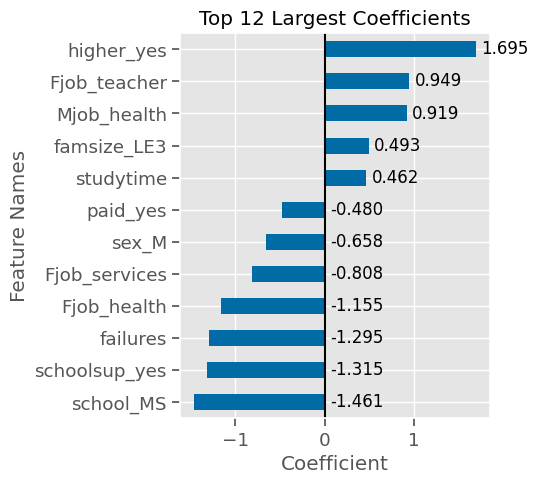

In [71]:
#  دالة get_coeffs_linreg وتشغيل كل شي
def get_coeffs_linreg(lin_reg, feature_names=None, sort=True,
                      ascending=True, name='LinearRegression Coefficients'):
    if feature_names is None:
        feature_names = lin_reg.feature_names_in_
    coeffs = pd.Series(lin_reg.coef_, index=feature_names)
    coeffs['intercept'] = lin_reg.intercept_
    if sort == True:
        coeffs = coeffs.sort_values(ascending=ascending)
    return coeffs

# Fit and visualize
lin_reg = LinearRegression()
lin_reg.fit(X_train_df, y_train)
evaluate_regression(lin_reg, X_train_df, y_train, X_test_df, y_test)
coeffs = get_coeffs_linreg(lin_reg)
plot_coeffs(coeffs, top_n=12, annotate=True)

### Interpreting Our Coefficients

**Baseline (Intercept) = 7.87**
The model starts every student at 7.87 before
considering any features.

**Positive Coefficients (increase G3):**
- higher_yes = +1.69 → wanting higher education
  raises predicted grade by 1.69 points
- Fjob_teacher = +0.95 → father is a teacher
  raises grade by 0.95
- Mjob_health = +0.92 → mother works in healthcare
  raises grade by 0.92

**Negative Coefficients (decrease G3):**
- school_MS = -1.46 → attending MS school
  lowers grade by 1.46
- schoolsup_yes = -1.31 → getting extra school support
  lowers predicted grade by 1.31
  (Note: student likely needs help because they're already struggling)
- failures = -1.29 → each past failure
  lowers grade by 1.29 points

#**From Regression to Classification**

## Moving From Regression to Classification

Regression without G1 & G2 gave us R² = 0.35 — too weak.
The stakeholder doesn't need the exact grade.
They just need to know: will this student fail or not?

Solution: Convert to Binary Classification
→ Much better Recall = 0.87 ✅

### Step 1 — Convert G3 to Percentage

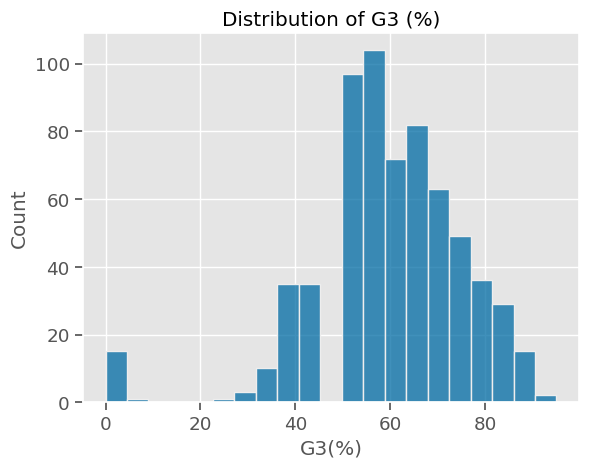

In [72]:
# Convert G3 to percentage out of 100
df['G3(%)'] = (df['G3'] / 20) * 100

# Visualize distribution
ax = sns.histplot(data=df, x='G3(%)')
ax.set_title('Distribution of G3 (%)')
plt.show()

### Step 2 — Bin Grades Using pd.cut

pd.cut splits numeric values into labeled categories.

Important notes:
- right=False → excludes right edge [0,60) not (0,60]
- Last bin = 101 to include score of 100
- include_lowest=True → includes 0 in first bin

In [73]:
# Define bin edges and labels
bins = [0, 60, 70, 80, 90, 101]
bin_labels = ['F', 'D', 'C', 'B', 'A']

# Add FinalGrade column
df['FinalGrade'] = pd.cut(df['G3(%)'], bins,
                          labels=bin_labels,
                          include_lowest=True)

# Verify min/max per grade
df.groupby('FinalGrade')['G3(%)'].agg(['min', 'max', 'count'])

,min,max,count
FinalGrade,,,
F,0.0,60.0,373
D,65.0,70.0,145
C,75.0,80.0,85
B,85.0,90.0,44
A,95.0,95.0,2


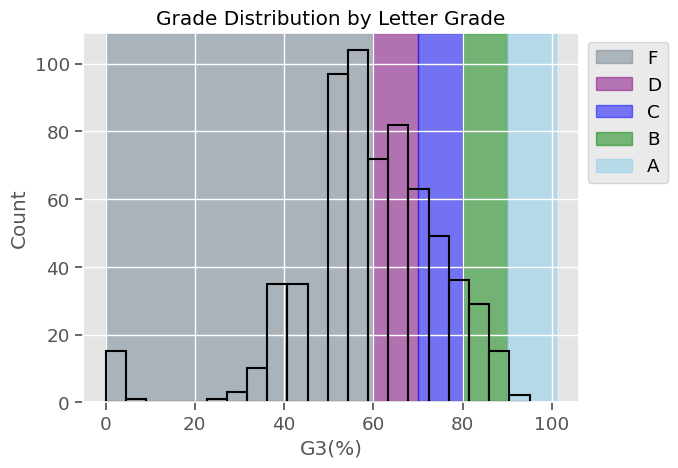

In [74]:
# Visualize grade cutoffs with color regions
ax = sns.histplot(data=df, x='G3(%)', color='k', fill=False)
colors = ['slategray', 'purple', 'blue', 'green', 'skyblue']

for i in range(len(bins)-1):
    x1 = bins[i]
    x2 = bins[i+1]
    label = bin_labels[i]
    ax.axvspan(x1, x2, label=label, color=colors[i], zorder=0, alpha=.5)

ax.legend(bbox_to_anchor=[1, 1])
plt.title('Grade Distribution by Letter Grade')
plt.show()

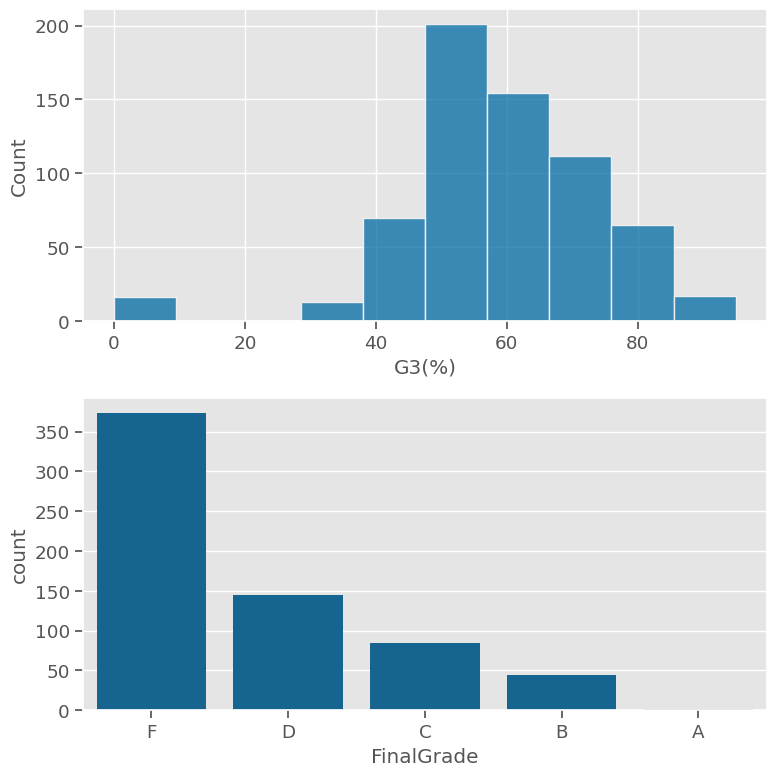

In [75]:
# Side by side view
fig, axes = plt.subplots(nrows=2, figsize=(8, 8))
sns.histplot(data=df, x='G3(%)', ax=axes[0], binwidth=10)
sns.countplot(data=df, x='FinalGrade', ax=axes[1],
              order=['F', 'D', 'C', 'B', 'A'])
plt.tight_layout()
plt.show()

### Step 3 — Create Binary Target

target_F = True  → student will FAIL ❌

target_F = False → student will PASS ✅

In [76]:
# Define binary target
df['target_F'] = df['FinalGrade'] == 'F'

print('Class Distribution:')
print(df['target_F'].value_counts())
print(f'\nClass Balance:')
print(df['target_F'].value_counts(normalize=True).round(3))

Class Distribution:
target_F
True     373
False    276
Name: count, dtype: int64

Class Balance:
target_F
True     0.575
False    0.425
Name: proportion, dtype: float64


### Step 4 — Train Test Split

⚠️ Important: Remove G1, G2, G3, G3(%), FinalGrade

These columns are derived directly from G3 —

keeping them would cause data leakage!

In [77]:
# Remove all grade-related columns to prevent leakage
drop_feats = ['G1', 'G2', 'G3', 'G3(%)', 'FinalGrade']
y = df['target_F'].copy()
X = df.drop(columns=['target_F', *drop_feats]).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (486, 30) | X_test: (163, 30)


### Step 5 — Preprocessing

New concept: make_column_selector

Instead of manually listing column names,

it automatically selects columns by dtype.

In [80]:
from sklearn.compose import make_column_selector

In [82]:

# Categorical pipeline
cat_cols = make_column_selector(dtype_include='object')
cat_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(drop='if_binary', sparse_output=False)
)
ohe_tuple = ('categorical', cat_pipe, cat_cols)

In [83]:
# Numeric pipeline
num_cols = make_column_selector(dtype_include='number')
num_pipe = make_pipeline(SimpleImputer(strategy='mean'))
num_tuple = ('numeric', num_pipe, num_cols)

In [84]:
# Create ColumnTransformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple],
                                  verbose_feature_names_out=False)

# Fit and transform
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

X_train_tf = pd.DataFrame(preprocessor.transform(X_train),
                           columns=feature_names, index=X_train.index)
X_test_tf = pd.DataFrame(preprocessor.transform(X_test),
                          columns=feature_names, index=X_test.index)

print(f'Features: {len(feature_names)}')
X_test_tf.head(3)

Features: 43


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
104,15.0,3.0,4.0,1.0,2.0,0.0,5.0,4.0,4.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
284,18.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,5.0,2.0,5.0,5.0,4.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
579,18.0,1.0,3.0,1.0,1.0,0.0,4.0,3.0,3.0,2.0,3.0,3.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


### Step 6 — RandomForest Classifier

Key metric: Recall for True (failing students)

→ We cannot afford to miss at-risk students!

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=SEED)
rf_clf.fit(X_train_tf, y_train)
evaluate_classification(rf_clf, X_train_tf, y_train, X_test_tf, y_test)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       205
        True       1.00      1.00      1.00       281

    accuracy                           1.00       486
   macro avg       1.00      1.00      1.00       486
weighted avg       1.00      1.00      1.00       486


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.81      0.70      0.75        71
        True       0.79      0.87      0.83        92

    accuracy                           0.80       163
   macro avg       0.80      0.79      0.79       163
weighted avg       0.80      0.80      0.8

### Step 7 — Feature Importance + Permutation Importance

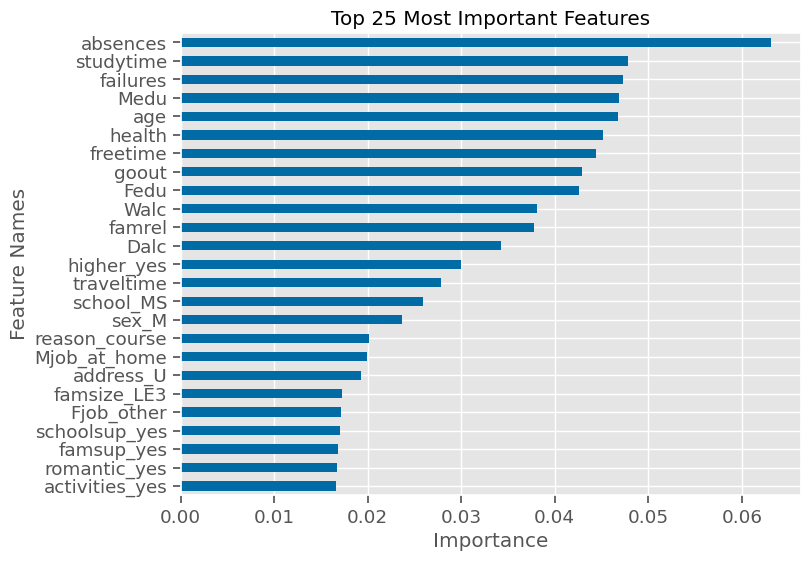

In [88]:
# Extract and plot feature importances
rf_importances = get_importances(rf_clf)
ax = plot_importance(rf_importances, top_n=25)
plt.show()

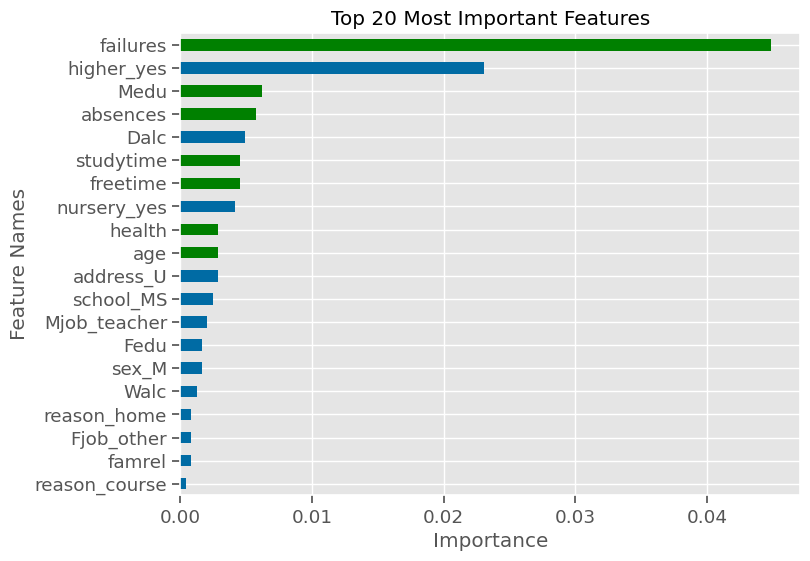

In [89]:
from sklearn.inspection import permutation_importance

r = permutation_importance(rf_clf, X_train_tf, y_train,
                           n_jobs=-1, n_repeats=5, random_state=SEED)

# Color coding top 7 from built-in
colors_rf = get_color_dict(rf_importances, top_n=7)

# Convert to Series
rf_perm_importances = pd.Series(r['importances_mean'],
                                index=X_train_tf.columns,
                                name='permutation importance')
rf_perm_importances = rf_perm_importances.sort_values(ascending=False)

# Plot
plot_importance_color(rf_perm_importances,
                      color_dict=colors_rf, top_n=20)
plt.show()

### Step 8 — Post-Modeling EDA

Now we visualize the relationship between
our top features and the target (target_F).

In [90]:
# Combine all data for EDA
plot_df_train = pd.concat([X_train_tf, y_train], axis=1)
plot_df_test = pd.concat([X_test_tf, y_test], axis=1)
plot_df = pd.concat([plot_df_train, plot_df_test])
plot_df.head(3)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,target_F
54,15.0,3.0,3.0,1.0,1.0,0.0,5.0,3.0,4.0,4.0,4.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,False
208,16.0,2.0,3.0,2.0,1.0,0.0,5.0,3.0,3.0,1.0,1.0,3.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,True
23,16.0,2.0,2.0,2.0,2.0,0.0,5.0,4.0,4.0,2.0,4.0,5.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,True


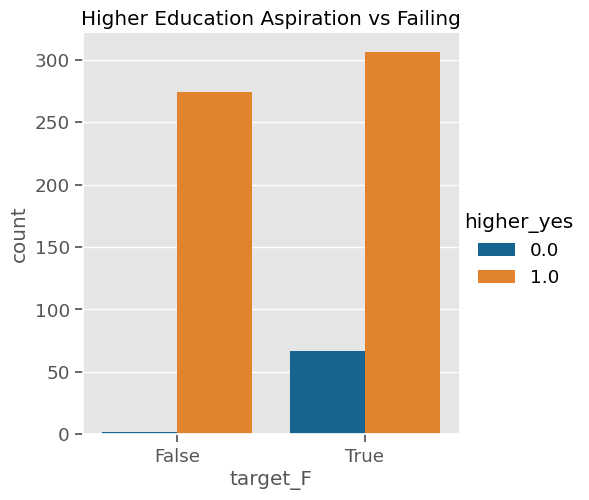

In [91]:
sns.catplot(data=plot_df, kind='count',
            x='target_F', hue='higher_yes')
plt.title('Higher Education Aspiration vs Failing')
plt.show()

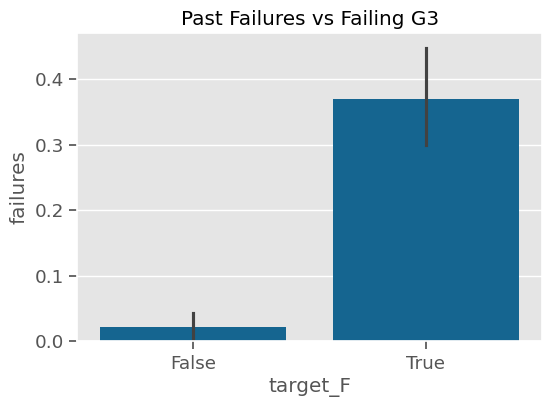

In [92]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_df, x='target_F', y='failures')
ax.set_title('Past Failures vs Failing G3')
plt.show()

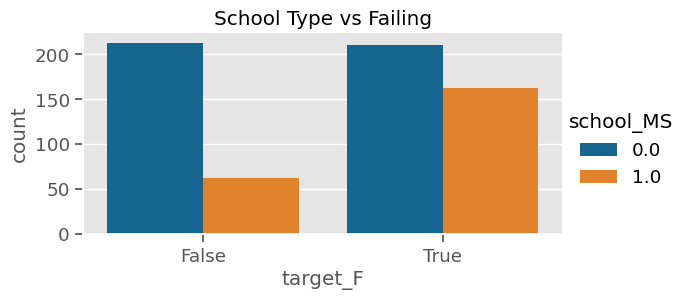

In [93]:
sns.catplot(data=plot_df, kind='count',
            x='target_F', hue='school_MS',
            aspect=2, height=3)
plt.title('School Type vs Failing')
plt.show()

### Key Findings

| | Regression | Classification |
|--|--|--|
| Performance | R² = 0.35 ❌ | Recall = 0.87 ✅ |
| Useful for stakeholder? | Less | More ✅ |
| Early intervention? | Hard | Possible ✅ |

Top features for predicting failure:
- absences: more absences → higher risk of failing
- failures: past failures → strong predictor
- higher_yes: no higher education plans → higher risk